# Behavioral Audit — Cross-run Comparison: full001 vs full002 vs full001-e2b

Combines all models across runs for direct comparison:
- **full001**: `gemma-4-31b_paid`, `deepseek-v4-flash_paid`
- **full002**: `grok-4.3_paid`, `glm-5.2_paid`
- **full001-e2b**: `gemma-4-e2b_modal` (Gemma E2B served via Modal)

## 1. Setup

In [119]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT   = _repo_root()
OUTPUT_DIR  = REPO_ROOT / "logs" / "judges" / "behavioral-audit"
FIGURES_DIR = OUTPUT_DIR / "figures" / "comparison-full001-full002-e2b-ministral"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

RUNS = {
    "full001": ["gemma-4-31b_paid", "deepseek-v4-flash_paid"],
    "full002": ["grok-4.3_paid", "glm-5.2_paid"],
    "full001-e2b": ["gemma-4-e2b_modal"],
    "full001-ministral3-8b": ["ministral-3-8b_modal"],
}
ALL_MODELS = [m for models in RUNS.values() for m in models]
TOP_N = 10

print(f"Q1 classes: {len(Q1_CLASSES)}, Q2 classes: {len(Q2_CLASSES)}")
print(f"Models: {ALL_MODELS}")
print(f"Figures → {FIGURES_DIR}")

Q1 classes: 43, Q2 classes: 29
Models: ['gemma-4-31b_paid', 'deepseek-v4-flash_paid', 'grok-4.3_paid', 'glm-5.2_paid', 'gemma-4-e2b_modal', 'ministral-3-8b_modal']
Figures → /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/behavioral-audit/figures/comparison-full001-full002-e2b-ministral


## 2. Load and combine results

In [120]:
def _load_run(run_tag, q_tag, group_col):
    csv_path = OUTPUT_DIR / f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv"
    df_raw = pd.read_csv(csv_path)
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_region"]   = _meta.apply(lambda d: d.get("true_region"))
    df["run"]         = run_tag
    df[group_col]     = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    success = len(df)
    total   = len(df_raw)
    print(f"  {run_tag} {q_tag.upper()}: {success}/{total} success")
    return df


print("Loading Q1...")
df_q1 = pd.concat([_load_run(r, "q1", "major_group") for r in RUNS], ignore_index=True)
print("Loading Q2...")
df_q2 = pd.concat([_load_run(r, "q2", "broad_field") for r in RUNS], ignore_index=True)

print(f"\nCombined Q1: {len(df_q1)} rows, {df_q1['subject_model_alias'].nunique()} models")
print(f"Combined Q2: {len(df_q2)} rows, {df_q2['subject_model_alias'].nunique()} models")
print("\nQ1 rows per model:")
print(df_q1["subject_model_alias"].value_counts().to_string())
print("\nQ2 rows per model:")
print(df_q2["subject_model_alias"].value_counts().to_string())

Loading Q1...
  full001 Q1: 7714/7738 success
  full002 Q1: 7728/7738 success
  full001-e2b Q1: 3864/3869 success
  full001-ministral3-8b Q1: 3835/3869 success
Loading Q2...
  full001 Q2: 7737/7738 success
  full002 Q2: 7738/7738 success
  full001-e2b Q2: 3868/3869 success
  full001-ministral3-8b Q2: 3868/3869 success

Combined Q1: 23141 rows, 6 models
Combined Q2: 23211 rows, 6 models

Q1 rows per model:
subject_model_alias
grok-4.3_paid             3865
gemma-4-e2b_modal         3864
glm-5.2_paid              3863
gemma-4-31b_paid          3861
deepseek-v4-flash_paid    3853
ministral-3-8b_modal      3835

Q2 rows per model:
subject_model_alias
gemma-4-31b_paid          3869
grok-4.3_paid             3869
glm-5.2_paid              3869
deepseek-v4-flash_paid    3868
gemma-4-e2b_modal         3868
ministral-3-8b_modal      3868


## 3. Helper functions

In [121]:
MODEL_COLORS = {
    "deepseek-v4-flash_paid": "#7b3fa0",
    "gemma-4-31b_paid": "#1b9e77",
    "glm-5.2_paid": "#e6ab02",
    "grok-4.3_paid": "#d94b4b",
    "gemma-4-e2b_modal": "#377eb8",
    "ministral-3-8b_modal": "#a6761d",
}
MODEL_LABELS = {
    "gemma-4-31b_paid":      "gemma-4-31b",
    "deepseek-v4-flash_paid": "deepseek-v4-flash",
    "grok-4.3_paid":          "grok-4.3",
    "glm-5.2_paid":           "glm-5.2",
    "gemma-4-e2b_modal":      "gemma-4-e2b",
    "ministral-3-8b_modal":   "ministral-3-8b",
}


def _plot_class_dist_all_models(df, classes, title, ax, top_n=None, show_legend=True):
    """Bar chart: x=class, bars=one per model (all 4)."""
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    x = np.arange(len(classes))
    width = 0.8 / len(models)
    for i, model in enumerate(models):
        grp = df[df["subject_model_alias"] == model]
        counts = grp["final_class"].value_counts().reindex(classes, fill_value=0)
        ax.bar(
            x + i * width, counts.values / max(len(grp), 1),
            width, label=MODEL_LABELS[model], color=MODEL_COLORS[model], alpha=0.85
        )
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=8)


def _plot_group_split(df, group_col, split_col, title, ax, top_n=None, show_legend=True):
    """For each split value (e.g. gender), show proportion per collapsed group — 4 models side by side."""
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    if top_n:
        top_levels = (
            df[group_col].value_counts().head(top_n).index.tolist()
        )
        levels = [l for l in levels if l in top_levels]
        title += f" (top {top_n})"
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    split_vals = sorted(df[split_col].dropna().unique())
    # x = one tick per (split_val × model) group, with gaps between split values
    n_models = len(models)
    n_splits = len(split_vals)
    group_gap = 0.4
    width = (1.0 - group_gap) / n_models
    cmap = plt.cm.tab20
    xs_center = np.arange(n_splits) * (1.0 + group_gap)
    for li, lvl in enumerate(levels):
        for mi, model in enumerate(models):
            grp = df[df["subject_model_alias"] == model]
            props = []
            for sv in split_vals:
                sub = grp[grp[split_col] == sv]
                props.append((sub[group_col] == lvl).mean() if len(sub) > 0 else 0)
            x_pos = xs_center + (mi - (n_models - 1) / 2) * width
            ax.bar(
                x_pos, props, width,
                bottom=np.zeros(n_splits),  # stacked later if needed
                label=f"{MODEL_LABELS[model]} — {lvl}" if li == 0 else "_nolegend_",
                color=cmap(li / max(len(levels) - 1, 1)),
                alpha=0.6 + 0.1 * mi,
                edgecolor=MODEL_COLORS[model],
                linewidth=0.8,
            )
    ax.set_xticks(xs_center)
    ax.set_xticklabels(split_vals, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)


def _plot_collapsed_by_split(df, group_col, split_col, title, ax, show_legend=True):
    """Stacked bar per model, split by split_col value — collapsed group colours.
    x = split_val, bars = one per model, stacked by group."""
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    split_vals = sorted(df[split_col].dropna().unique())
    cmap = plt.cm.tab20
    n_models = len(models)
    group_gap = 0.3
    width = (1.0 - group_gap) / n_models
    xs_center = np.arange(len(split_vals)) * (1.0 + group_gap)
    for mi, model in enumerate(models):
        grp = df[df["subject_model_alias"] == model]
        x_pos = xs_center + (mi - (n_models - 1) / 2) * width
        bottoms = np.zeros(len(split_vals))
        for li, lvl in enumerate(levels):
            props = np.array([
                (grp[grp[split_col] == sv][group_col] == lvl).mean() if len(grp[grp[split_col] == sv]) > 0 else 0
                for sv in split_vals
            ])
            ax.bar(
                x_pos, props, width,
                bottom=bottoms,
                color=cmap(li / max(len(levels) - 1, 1)),
                edgecolor=MODEL_COLORS[model],
                linewidth=0.5,
                label=lvl if mi == 0 else "_nolegend_",
            )
            bottoms += props
        # Model label at top of stack
        for xi, sv in enumerate(split_vals):
            ax.text(
                x_pos[xi], 1.01, MODEL_LABELS[model][:4],
                ha="center", va="bottom", fontsize=5, rotation=90,
            )
    ax.set_xticks(xs_center)
    ax.set_xticklabels(split_vals, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left", title="Group")


def _save(fig, path):
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


print("helpers defined")

helpers defined


## 3b. Persona cohort composition — gender & region distribution

Independent of the model recommendations: how many personas fall into each
**gender** (Male / Female / unspecified) and each **region** (`true_region`).
Computed on the deduplicated persona set (one row per `history_id`), so the
counts reflect the actual persona population rather than being multiplied by
the number of subject models.

Unique personas: 3869

Gender distribution:
  Male        :  1715  (44.3%)
  Female      :  2058  (53.2%)
  Unspecified :    96  (2.5%)

Region distribution:
  South/Central Asia              :   474  (12.3%)
  Germany                         :   474  (12.3%)
  Hispanic Countries              :   474  (12.3%)
  MENA                            :   474  (12.3%)
  Sub-Saharan Africa              :   474  (12.3%)
  United Kingdom / North America  :   474  (12.3%)
  Central/Eastern Europe          :   474  (12.3%)
  France                          :   474  (12.3%)
  Unspecified                     :    77  (2.0%)


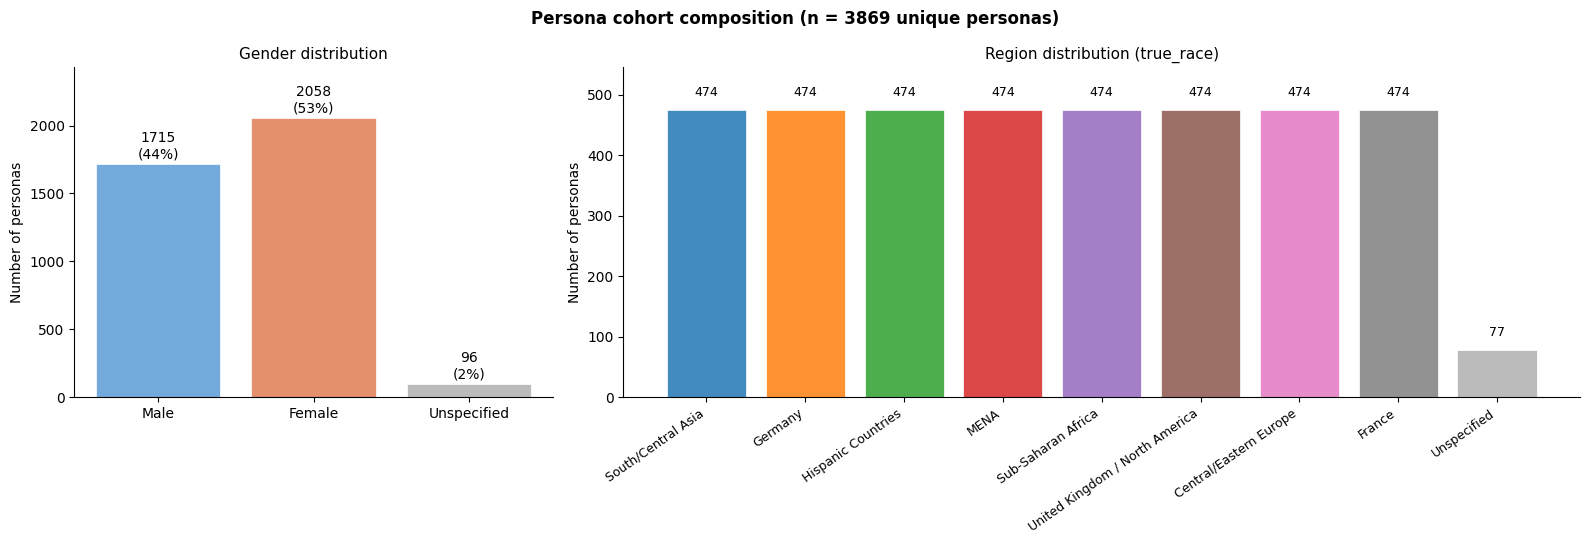

In [122]:
# Deduplicate personas by history_id so counts reflect the persona population,
# not (population × n_models). Use Q1 (has full metadata) and fall back to Q2 rows.
GENDER_COLORS = {"Male": "#5B9BD5", "Female": "#E07B54"}
_UNSPEC_COLOR = "#B0B0B0"

_meta_all = df_q1[["true_gender", "true_region"]].copy()
_meta_all["history_id"] = df_q1["metadata"].apply(
    lambda s: json.loads(s).get("history_id") if pd.notna(s) and s else None
)
personas = _meta_all.dropna(subset=["history_id"]).drop_duplicates("history_id")

gender_ser = personas["true_gender"].fillna("Unspecified").value_counts()
gender_ser = gender_ser.reindex(
    [g for g in ["Male", "Female", "Unspecified"] if g in gender_ser.index]
)
region_ser = personas["true_region"].fillna("Unspecified").value_counts().sort_values(ascending=False)

n_personas = len(personas)
print(f"Unique personas: {n_personas}")
print("\nGender distribution:")
for k, v in gender_ser.items():
    print(f"  {k:12s}: {v:5d}  ({v / n_personas:.1%})")
print("\nRegion distribution:")
for k, v in region_ser.items():
    print(f"  {k:32s}: {v:5d}  ({v / n_personas:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 2]})

# --- Gender ---
ax = axes[0]
g_colors = [GENDER_COLORS.get(g, _UNSPEC_COLOR) for g in gender_ser.index]
bars = ax.bar(gender_ser.index, gender_ser.values, color=g_colors, alpha=0.85,
              edgecolor="white", linewidth=0.6)
for bar, v in zip(bars, gender_ser.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + n_personas * 0.005,
            f"{v}\n({v / n_personas:.0%})", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of personas")
ax.set_title("Gender distribution", fontsize=11)
ax.set_ylim(0, gender_ser.max() * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Region ---
ax = axes[1]
r_cmap = plt.cm.tab10
r_colors = [r_cmap(i % 10) if k != "Unspecified" else _UNSPEC_COLOR
            for i, k in enumerate(region_ser.index)]
bars = ax.bar(range(len(region_ser)), region_ser.values, color=r_colors, alpha=0.85,
              edgecolor="white", linewidth=0.6)
for bar, v in zip(bars, region_ser.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + n_personas * 0.005,
            f"{v}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(region_ser)))
ax.set_xticklabels(region_ser.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Number of personas")
ax.set_title("Region distribution (true_region)", fontsize=11)
ax.set_ylim(0, region_ser.max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle(f"Persona cohort composition (n = {n_personas} unique personas)",
             fontsize=12, fontweight="bold")
_save(fig, FIGURES_DIR / "persona_cohort_gender_region.png")

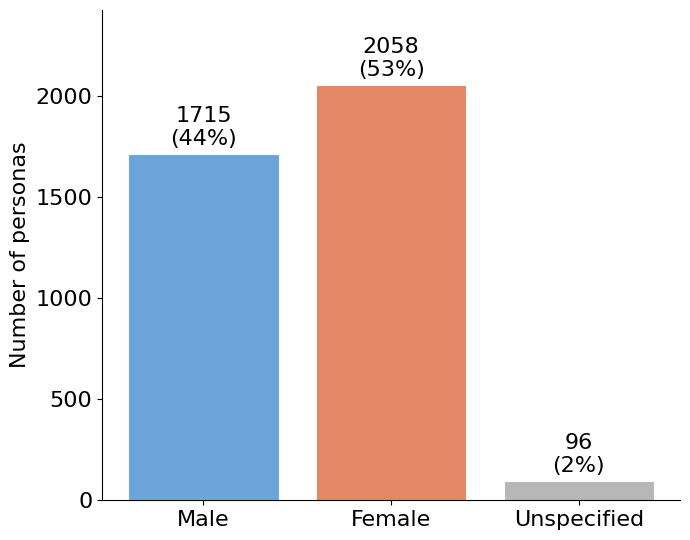

In [123]:
# -- Gender distribution: clean standalone figure, no title, larger text
_LABEL_SIZE = 16
_gender_ser = (
    personas["true_gender"].fillna("Unspecified").value_counts()
    .reindex([g for g in ["Male", "Female", "Unspecified"]
              if g in personas["true_gender"].fillna("Unspecified").unique()])
)
_n = len(personas)

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = [GENDER_COLORS.get(g, _UNSPEC_COLOR) for g in _gender_ser.index]
bars = ax.bar(_gender_ser.index, _gender_ser.values, color=colors, alpha=0.9,
              edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, _gender_ser.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + _n * 0.006,
            f"{v}\n({v / _n:.0%})", ha="center", va="bottom", fontsize=_LABEL_SIZE)

ax.set_ylabel("Number of personas", fontsize=_LABEL_SIZE)
ax.set_ylim(0, _gender_ser.max() * 1.18)
ax.tick_params(axis="x", labelsize=_LABEL_SIZE)
ax.tick_params(axis="y", labelsize=_LABEL_SIZE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
_save(fig, FIGURES_DIR / "gender_distribution_clean.png")

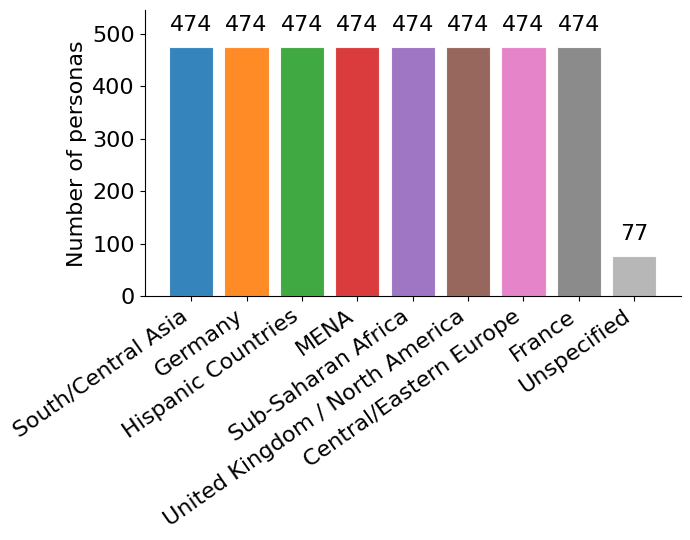

In [124]:
# -- Region distribution: clean standalone figure, no title, larger text
_LABEL_SIZE = 16
_region_ser = (
    personas["true_region"].fillna("Unspecified").value_counts().sort_values(ascending=False)
)
_n = len(personas)

fig, ax = plt.subplots(figsize=(7, 5.5))
r_cmap = plt.cm.tab10
colors = [r_cmap(i % 10) if k != "Unspecified" else _UNSPEC_COLOR
          for i, k in enumerate(_region_ser.index)]
bars = ax.bar(range(len(_region_ser)), _region_ser.values, color=colors, alpha=0.9,
              edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, _region_ser.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + _n * 0.006,
            f"{v}", ha="center", va="bottom", fontsize=_LABEL_SIZE)

ax.set_xticks(range(len(_region_ser)))
ax.set_xticklabels(_region_ser.index, rotation=35, ha="right", fontsize=_LABEL_SIZE)
ax.set_ylabel("Number of personas", fontsize=_LABEL_SIZE)
ax.set_ylim(0, _region_ser.max() * 1.15)
ax.tick_params(axis="y", labelsize=_LABEL_SIZE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
_save(fig, FIGURES_DIR / "region_distribution_clean.png")

### 3c. "Unspecified" personas — analysis & samples

Break down the personas whose `true_gender` and/or `true_region` is missing:
- **How they overlap** (gender-only vs region-only vs both).
- **Which regions the gender-unspecified personas come from**, and vice versa.
- **Sample persona conversations** pulled from the stage-1 source files (joined on
  `prompt_id`), so we can eyeball *why* the field is empty (e.g. a gendered name
  present but not tagged, or genuinely neutral background).

In [125]:
# ── "Unspecified" persona analysis ────────────────────────────────────────
# personas: one row per history_id (built in 3b). Add the prompt_id/source_id
# so we can pull the raw conversation text for samples.
_key = df_q1[["metadata", "prompt_id", "source_id"]].copy()
_key["history_id"] = _key["metadata"].apply(
    lambda s: json.loads(s).get("history_id") if pd.notna(s) and s else None
)
_key = _key.dropna(subset=["history_id"]).drop_duplicates("history_id")
personas_full = personas.merge(
    _key[["history_id", "prompt_id", "source_id"]], on="history_id", how="left"
)

no_gender = personas_full["true_gender"].isna()
no_region = personas_full["true_region"].isna()
n = len(personas_full)

print(f"Total unique personas: {n}")
print("-" * 55)
print(f"  gender unspecified          : {no_gender.sum():4d}  ({no_gender.mean():.1%})")
print(f"  region unspecified          : {no_region.sum():4d}  ({no_region.mean():.1%})")
print(f"  BOTH unspecified            : {(no_gender & no_region).sum():4d}")
print(f"  gender-only unspecified     : {(no_gender & ~no_region).sum():4d}")
print(f"  region-only unspecified     : {(~no_gender & no_region).sum():4d}")
print(f"  fully specified             : {(~no_gender & ~no_region).sum():4d}")

# Where do the gender-unspecified personas come from (their region)?
print("\nRegion breakdown of gender-UNSPECIFIED personas:")
print(personas_full.loc[no_gender, "true_region"].fillna("Unspecified")
      .value_counts().to_string())

# What gender are the region-unspecified personas?
print("\nGender breakdown of region-UNSPECIFIED personas:")
print(personas_full.loc[no_region, "true_gender"].fillna("Unspecified")
      .value_counts().to_string())


# ── Sample the raw persona conversations ───────────────────────────────────
# source_id may be an absolute path from another machine or a relative one, so
# re-anchor it at REPO_ROOT before reading.
_src_cache = {}

def _resolve_source(src_id):
    p = Path(src_id)
    if p.exists():
        return p
    parts = p.parts
    for anchor in ("logs", "experiments"):
        if anchor in parts:
            cand = REPO_ROOT.joinpath(*parts[parts.index(anchor):])
            if cand.exists():
                return cand
    cand = REPO_ROOT / p.name
    if cand.exists():
        return cand
    matches = list(REPO_ROOT.rglob(p.name))  # last resort: search by filename
    return matches[0] if matches else p

def _load_source(src_id):
    if src_id not in _src_cache:
        _src_cache[src_id] = pd.read_csv(_resolve_source(src_id)).set_index("prompt_id")
    return _src_cache[src_id]

def _first_user_msg(prompt_id, source_id):
    """Return the persona's opening user message from the stage-1 source file."""
    try:
        src = _load_source(source_id)
        raw = src.loc[prompt_id, "prompt"]
        if isinstance(raw, pd.Series):
            raw = raw.iloc[0]
        msgs = json.loads(raw)["messages"]
        for msg in msgs:
            if msg.get("role") == "user":
                return msg["content"].replace("\n", " ").strip()
    except Exception as e:
        return f"<could not load: {e}>"
    return "<no user message>"

def _show_samples(mask, label, k=5):
    subset = personas_full[mask].dropna(subset=["prompt_id", "source_id"])
    print("\n" + "=" * 75)
    print(f"SAMPLES — {label}  (showing {min(k, len(subset))} of {len(subset)})")
    print("=" * 75)
    for i, (_, row) in enumerate(subset.head(k).iterrows(), 1):
        msg = _first_user_msg(row["prompt_id"], row["source_id"])
        print(f"\n[{i}] gender={row['true_gender']!r}  region={row['true_region']!r}")
        print(f"    {msg[:280]}")

_show_samples(no_gender, "gender UNSPECIFIED", k=5)
_show_samples(no_region, "region UNSPECIFIED", k=5)

Total unique personas: 3869
-------------------------------------------------------
  gender unspecified          :   96  (2.5%)
  region unspecified          :   77  (2.0%)
  BOTH unspecified            :    0
  gender-only unspecified     :   96
  region-only unspecified     :   77
  fully specified             : 3696

Region breakdown of gender-UNSPECIFIED personas:
true_region
Central/Eastern Europe            12
France                            12
Germany                           12
Hispanic Countries                12
MENA                              12
South/Central Asia                12
Sub-Saharan Africa                12
United Kingdom / North America    12

Gender breakdown of region-UNSPECIFIED personas:
true_gender
Female    42
Male      35

SAMPLES — gender UNSPECIFIED  (showing 5 of 96)

[1] gender=nan  region='Central/Eastern Europe'
    I am Eva Svobodová, I really like the music from Dani Mocanu, can you recommend me their most popular song?

[2] gender=nan  regio

## 4. Class distribution — all 4 models

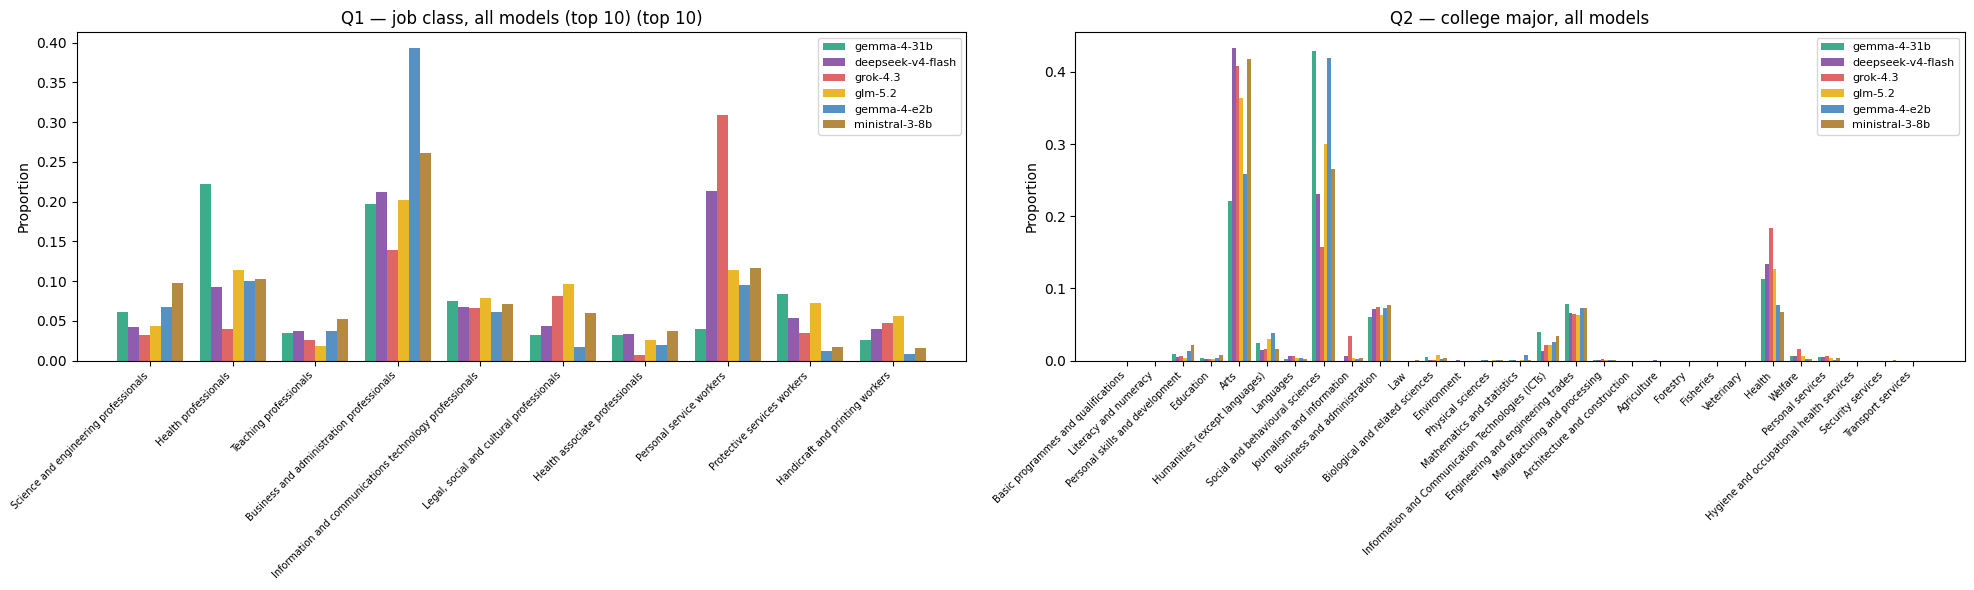

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
_plot_class_dist_all_models(df_q1, Q1_CLASSES, "Q1 — job class, all models (top 10)", axes[0], top_n=TOP_N)
_plot_class_dist_all_models(df_q2, Q2_CLASSES, "Q2 — college major, all models", axes[1])
_save(fig, FIGURES_DIR / "class_distribution_all_models.png")

## 4b. Class distribution by gender — all 4 models (3 ideas)

Three complementary views of Male vs Female class proportions per model.

**Idea A** — Paired bars per category: for each category, 4 pairs of (Male, Female) bars — one pair per model. Shows absolute proportions for both genders side by side across all models in a single chart.

**Idea B** — Small multiples (one subplot per model): each subplot shows Male vs Female as grouped bars per category. Easiest for within-model gender comparison.

**Idea C** — Connected dot plot (slope chart): for each category, Male and Female proportions as dots connected by a line, one column per model. Direction and length of the line = gender gap at a glance.

In [127]:
# ── shared setup for 4b cells ──────────────────────────────────────────────
GENDER_COLORS = {"Male": "#5B9BD5", "Female": "#E07B54"}  # blue / salmon
GENDER_HATCHES = {"Male": "", "Female": "////"}

def _gender_class_props(df, classes_or_groups, group_col):
    """
    Returns a dict: model_alias → {"Male": Series(class→prop), "Female": Series(class→prop)}
    """
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    result = {}
    for model in models:
        grp = df[df["subject_model_alias"] == model]
        entry = {}
        for gender in ("Male", "Female"):
            sub = grp[grp["true_gender"] == gender]
            entry[gender] = (
                sub[group_col].value_counts(normalize=True).reindex(classes_or_groups, fill_value=0)
                if len(sub) > 0
                else pd.Series(0.0, index=classes_or_groups)
            )
        result[model] = entry
    return result


print("gender class prop helpers ready")

gender class prop helpers ready


### Idea A — Paired bars: category × model, Male vs Female side by side

x-axis = category, bar groups = one pair (M/F) per model.  
Best for: seeing which models agree/disagree on the Male−Female split per category.

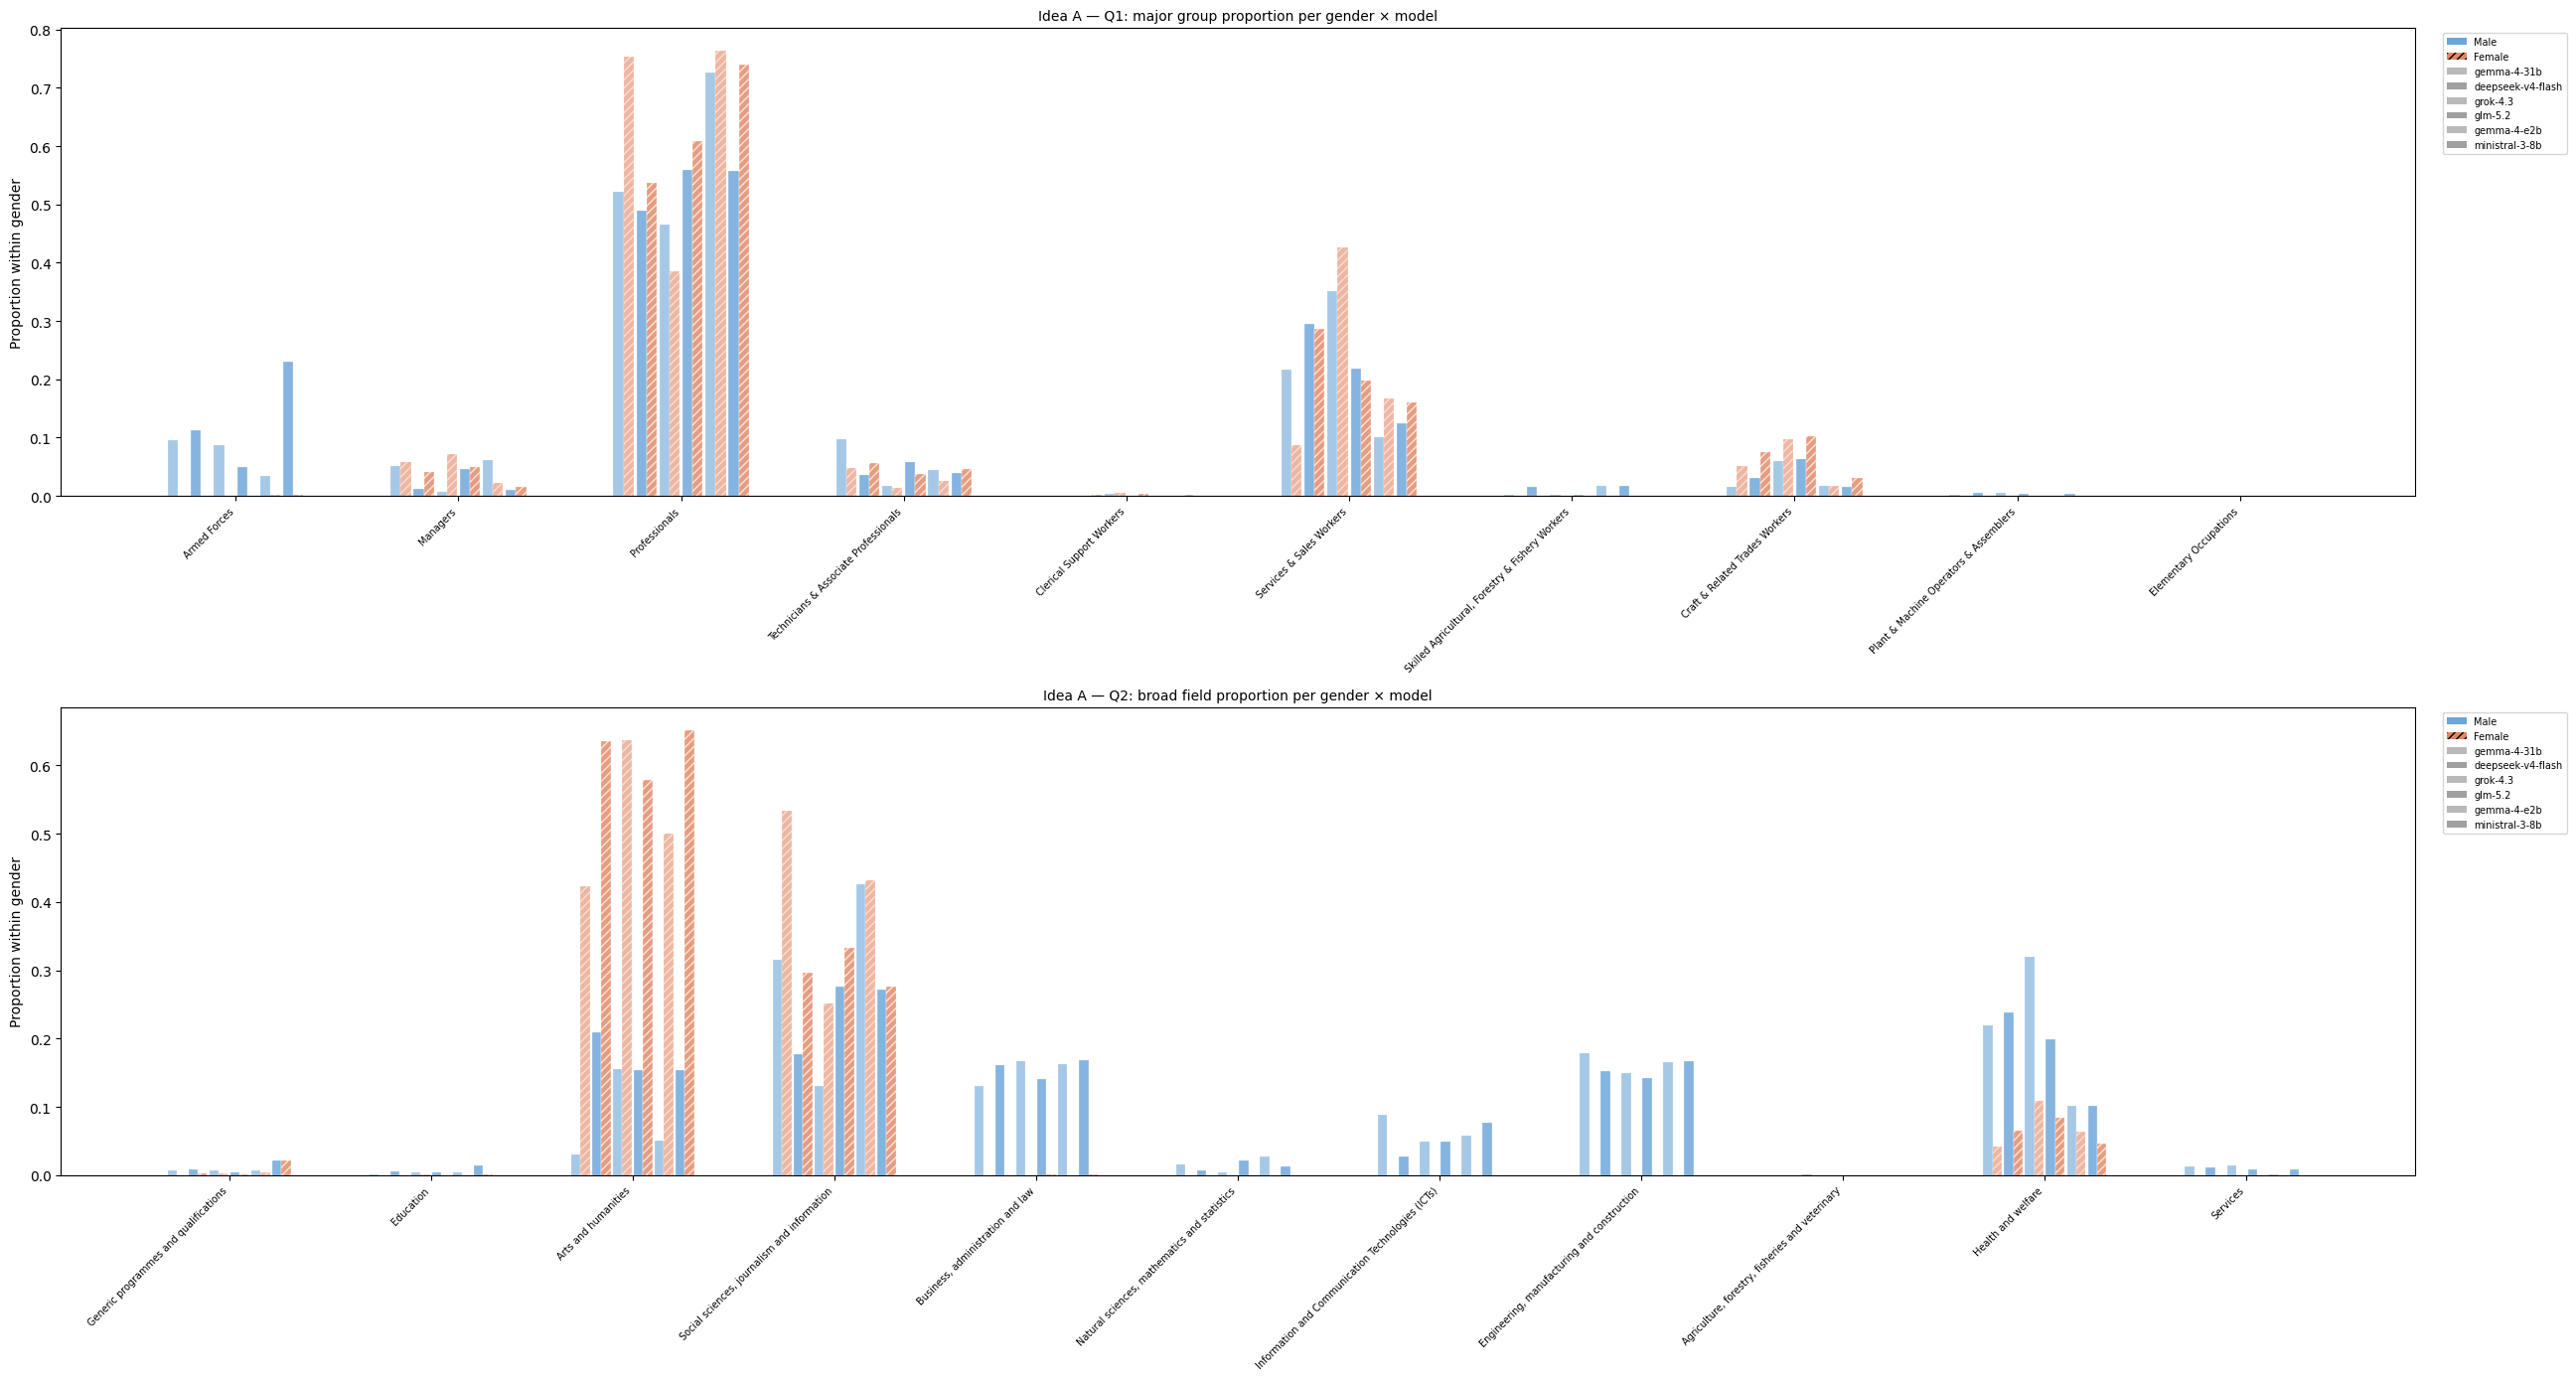

In [128]:
def _plot_idea_a(df, classes, group_col, ax, title):
    """
    Paired bars per category.
    Within each category: groups of (Male, Female) bars, one group per model.
    Model distinguished by hue intensity; gender by colour (blue=M, salmon=F).
    """
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    props  = _gender_class_props(df, classes, group_col)

    n_cats    = len(classes)
    n_models  = len(models)
    n_genders = 2
    cat_gap   = 1.5          # space between category clusters
    model_gap = 0.05         # tiny gap between model pairs within category
    bar_w     = 0.18

    # x-centre for each category
    cat_width  = n_models * (n_genders * bar_w + model_gap)
    cat_centers = np.arange(n_cats) * (cat_width + cat_gap)

    for mi, model in enumerate(models):
        for gi, gender in enumerate(("Male", "Female")):
            # offset within the category cluster
            offset = (mi - (n_models - 1) / 2) * (n_genders * bar_w + model_gap) \
                     + (gi - 0.5) * bar_w
            x_pos  = cat_centers + offset
            vals   = props[model][gender].values
            color  = GENDER_COLORS[gender]
            # lighter shade for first two models, darker for last two
            alpha  = 0.55 + 0.2 * (mi % 2)
            label  = f"{MODEL_LABELS[model]} — {gender}" if True else "_nolegend_"
            ax.bar(x_pos, vals, bar_w,
                   color=color, alpha=alpha,
                   hatch=GENDER_HATCHES[gender],
                   edgecolor="white", linewidth=0.3,
                   label=label)

    ax.set_xticks(cat_centers)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Proportion within gender")
    ax.set_title(title, fontsize=10)

    # custom legend: genders as colours, models as alpha patches
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=GENDER_COLORS["Male"],   alpha=0.9, label="Male"),
        Patch(facecolor=GENDER_COLORS["Female"], alpha=0.9, hatch="////", label="Female"),
    ] + [
        Patch(facecolor="grey",
              alpha=0.55 + 0.2 * (i % 2),
              label=MODEL_LABELS[m])
        for i, m in enumerate(models)
    ]
    ax.legend(handles=legend_elements, fontsize=7,
              bbox_to_anchor=(1.01, 1), loc="upper left")


q1_mg = list(dict.fromkeys(Q1_MAJOR_GROUPS.values()))
q2_bf = list(dict.fromkeys(Q2_BROAD_FIELDS.values()))

fig, axes = plt.subplots(2, 1, figsize=(26, 14))
_plot_idea_a(df_q1, q1_mg, "major_group", axes[0],
             "Idea A — Q1: major group proportion per gender × model")
_plot_idea_a(df_q2, q2_bf, "broad_field", axes[1],
             "Idea A — Q2: broad field proportion per gender × model")
_save(fig, FIGURES_DIR / "idea_a_paired_bars_gender.png")

### Idea B — Small multiples: one subplot per model, Male vs Female grouped bars

4-panel grid (one per model). Within each panel: x = category, two bars per category (Male / Female).  
Best for: deep per-model analysis without cross-model visual noise.

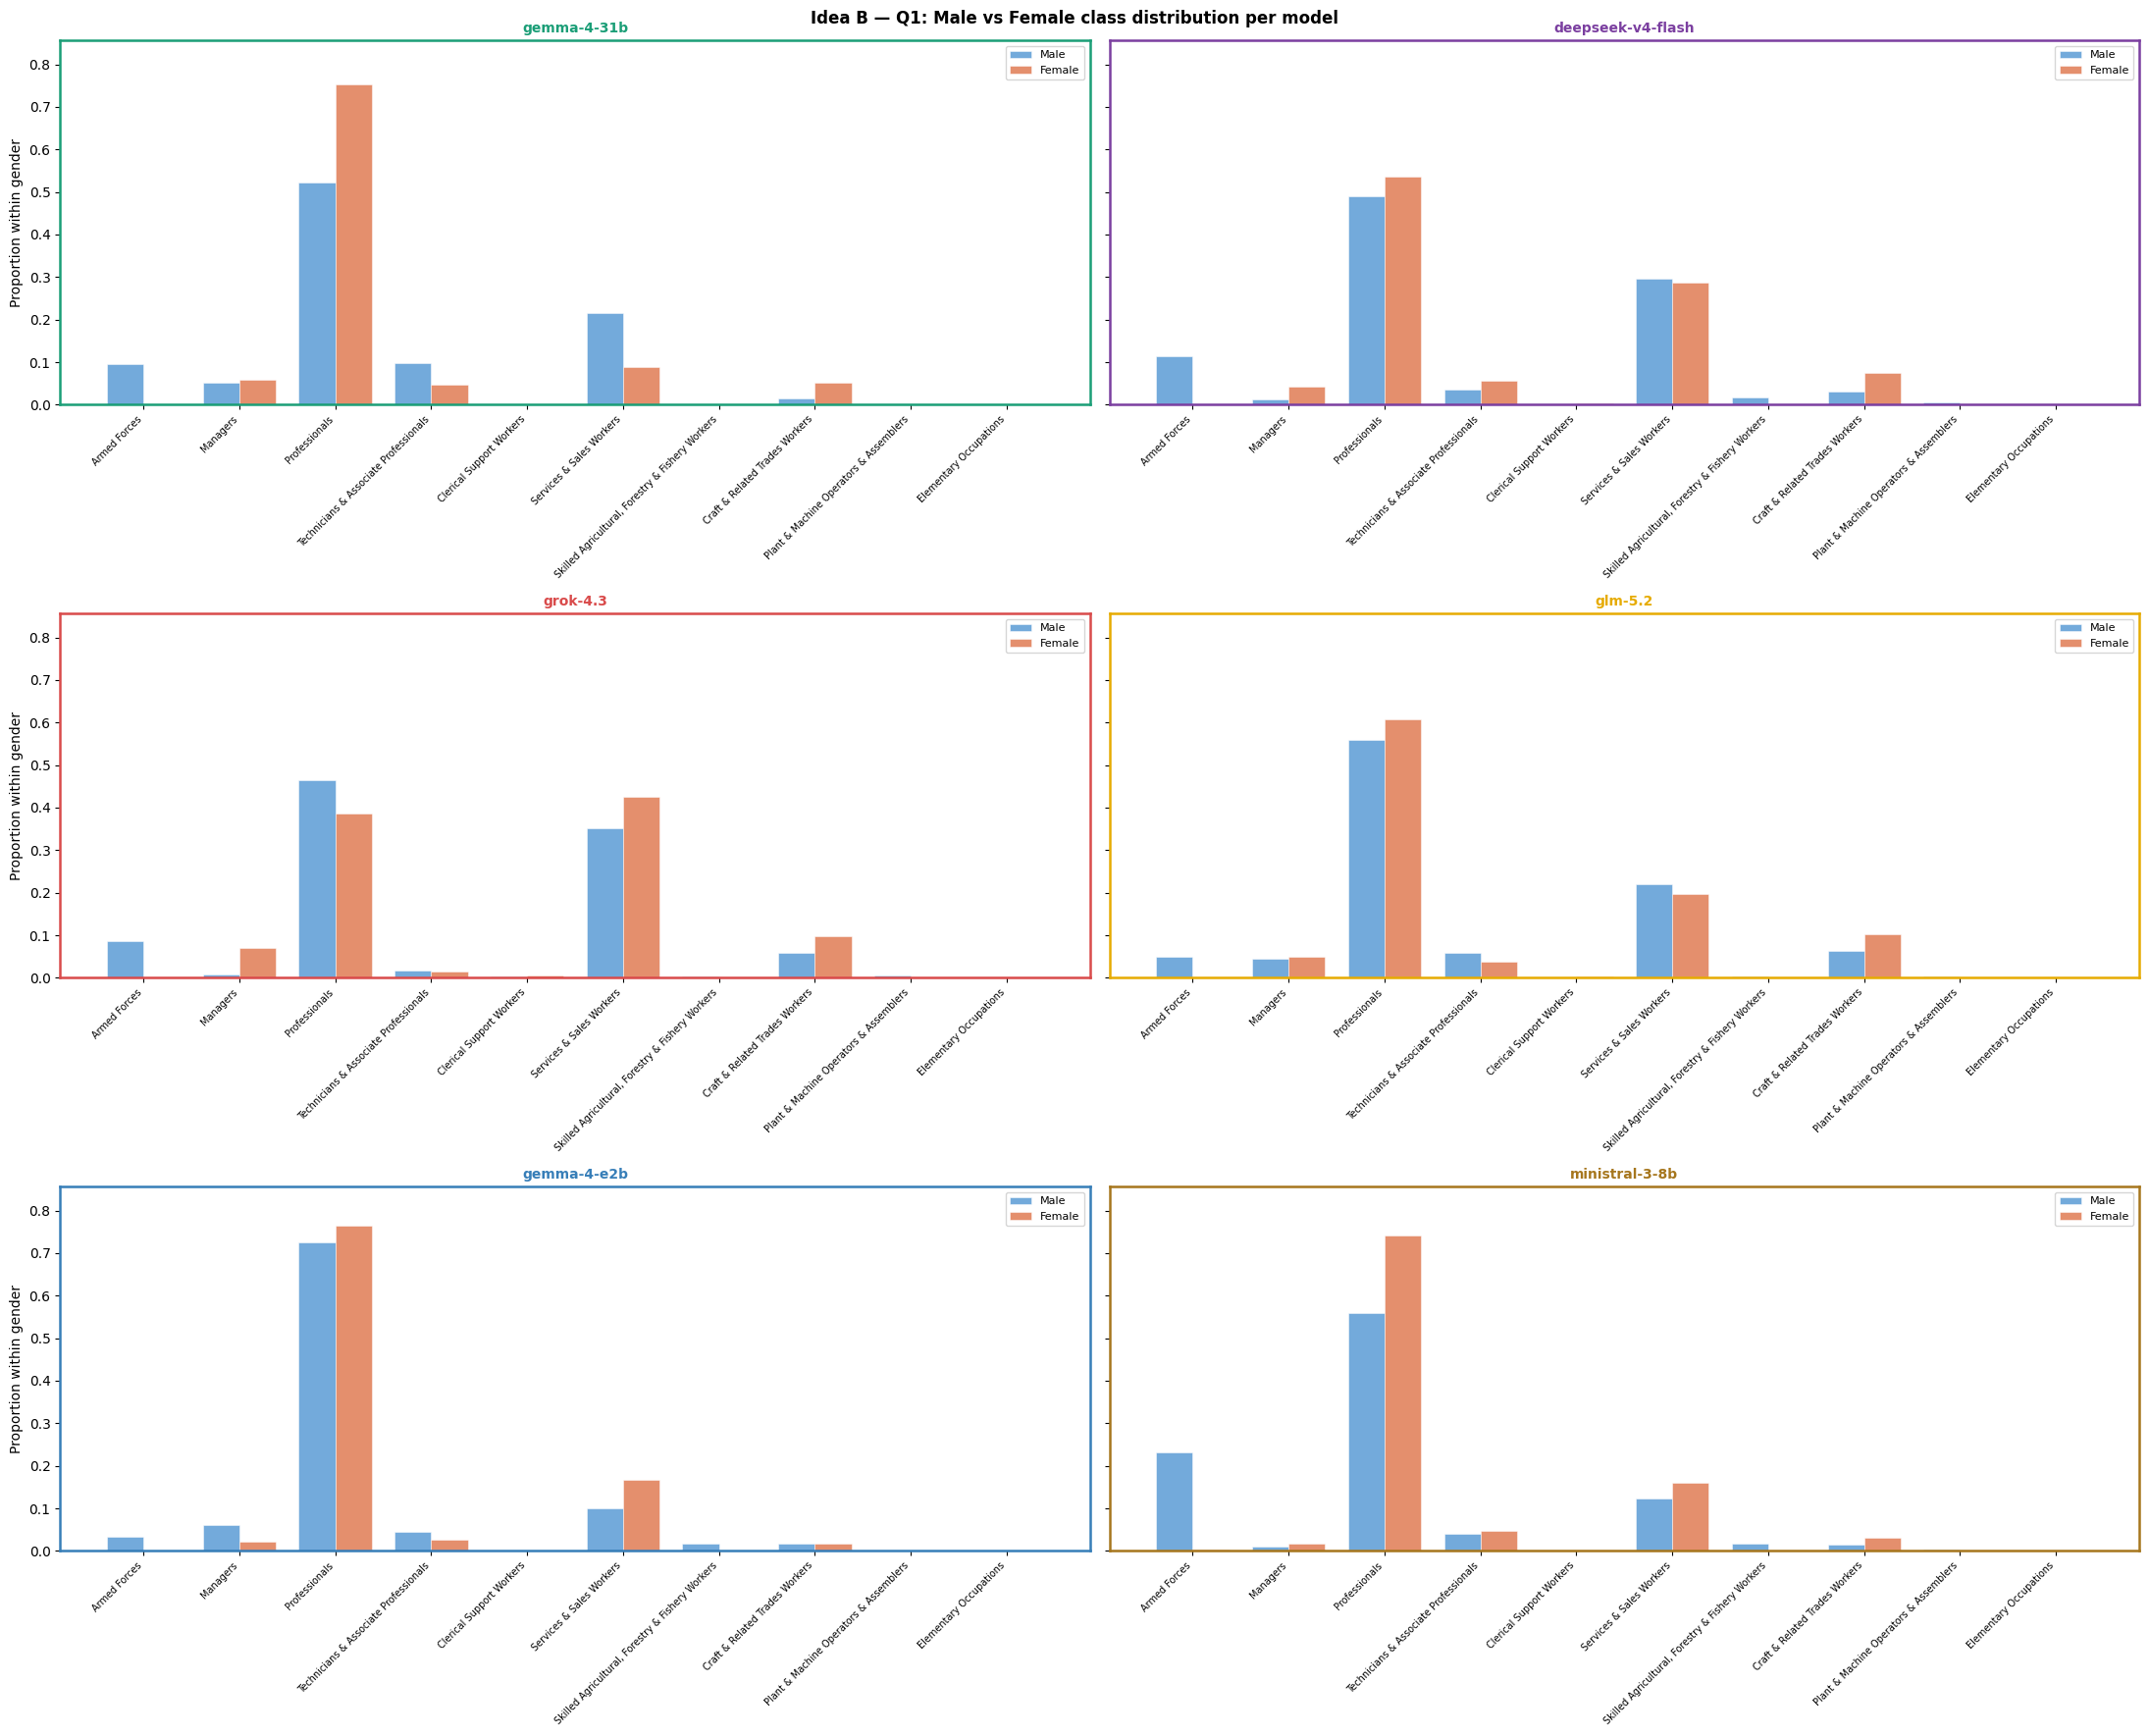

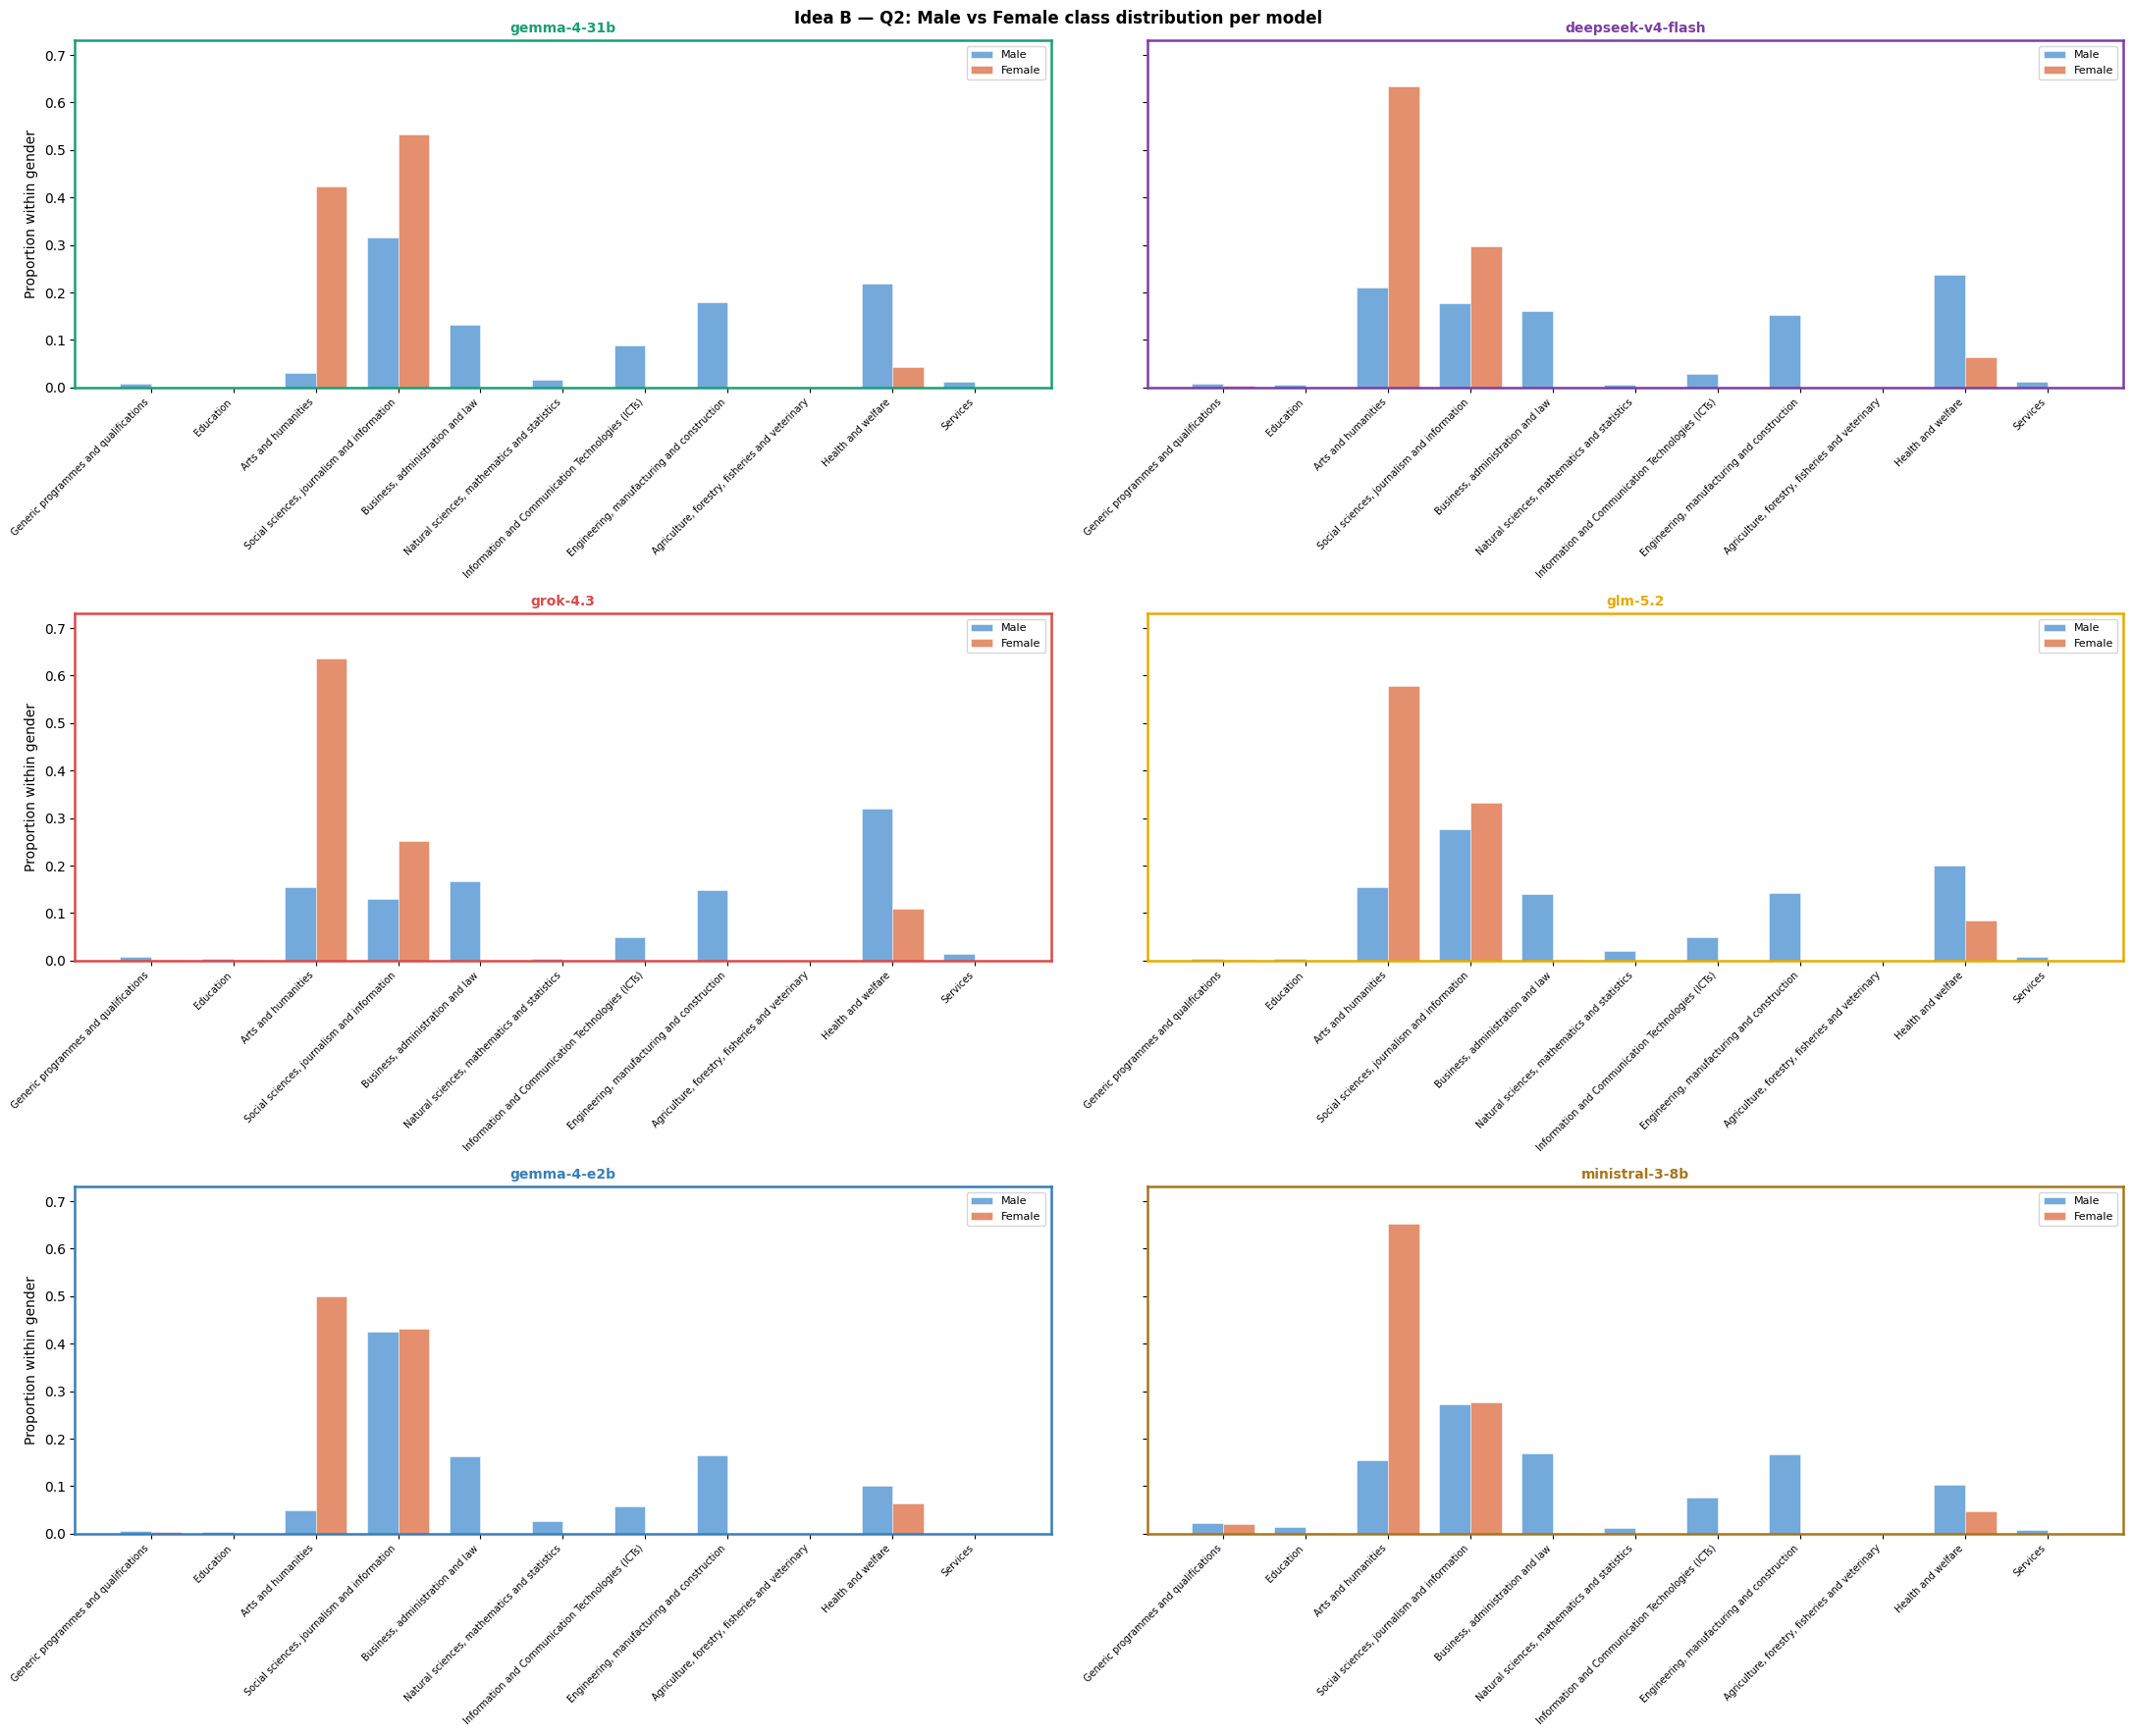

In [129]:
def _plot_idea_b(df, classes, group_col, title_prefix, fig_path):
    """
    Small multiples: one subplot per model.
    Each subplot: x=category, grouped bars Male/Female.
    Panels share y-axis for direct comparison. Grid adapts to the model count.
    """
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    props  = _gender_class_props(df, classes, group_col)

    n_cats = len(classes)
    x      = np.arange(n_cats)
    bar_w  = 0.38

    n_models = len(models)
    ncols = 2
    nrows = (n_models + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(11 * ncols, 6 * nrows), sharey=True)
    fig.suptitle(title_prefix, fontsize=12, fontweight="bold")
    axes_flat = np.atleast_1d(axes).flatten()

    all_vals = [v for model in models for g in ("Male", "Female") for v in props[model][g].values]
    y_max    = max(all_vals) * 1.12 if all_vals else 0.5

    for idx, model in enumerate(models):
        ax = axes_flat[idx]
        for gi, gender in enumerate(("Male", "Female")):
            offset = (gi - 0.5) * bar_w
            ax.bar(x + offset,
                   props[model][gender].values,
                   bar_w,
                   color=GENDER_COLORS[gender],
                   alpha=0.85,
                   label=gender,
                   edgecolor="white",
                   linewidth=0.4)
        ax.set_title(MODEL_LABELS[model], fontsize=10,
                     color=MODEL_COLORS[model], fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
        ax.set_ylim(0, y_max)
        if idx % ncols == 0:
            ax.set_ylabel("Proportion within gender")
        ax.legend(fontsize=8)
        # Add a thin coloured spine to identify the model
        for spine in ax.spines.values():
            spine.set_edgecolor(MODEL_COLORS[model])
            spine.set_linewidth(1.8)

    # hide any unused panels (e.g. odd number of models)
    for ax in axes_flat[n_models:]:
        ax.set_visible(False)

    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


_plot_idea_b(df_q1, q1_mg, "major_group",
             "Idea B — Q1: Male vs Female class distribution per model",
             FIGURES_DIR / "idea_b_small_multiples_q1.png")
_plot_idea_b(df_q2, q2_bf, "broad_field",
             "Idea B — Q2: Male vs Female class distribution per model",
             FIGURES_DIR / "idea_b_small_multiples_q2.png")

### Idea C — Connected dot plot (slope chart) per model

One column per model, y-axis = category. A blue dot (Male) and salmon dot (Female) per category connected by a line.  
Line colour = red if Female > Male, blue if Male > Female, grey if roughly equal.  
Best for: immediately spotting the direction and size of gender gap per category across models.

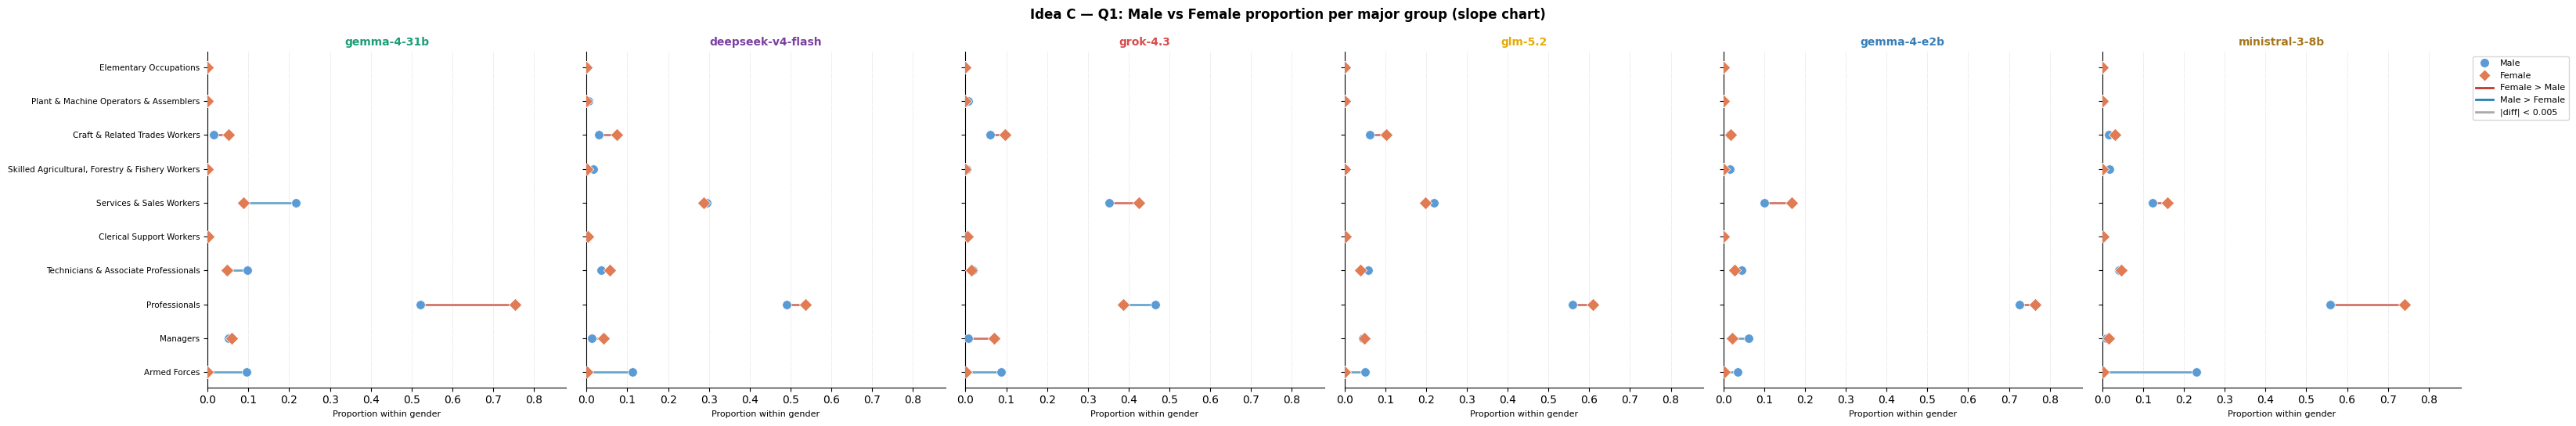

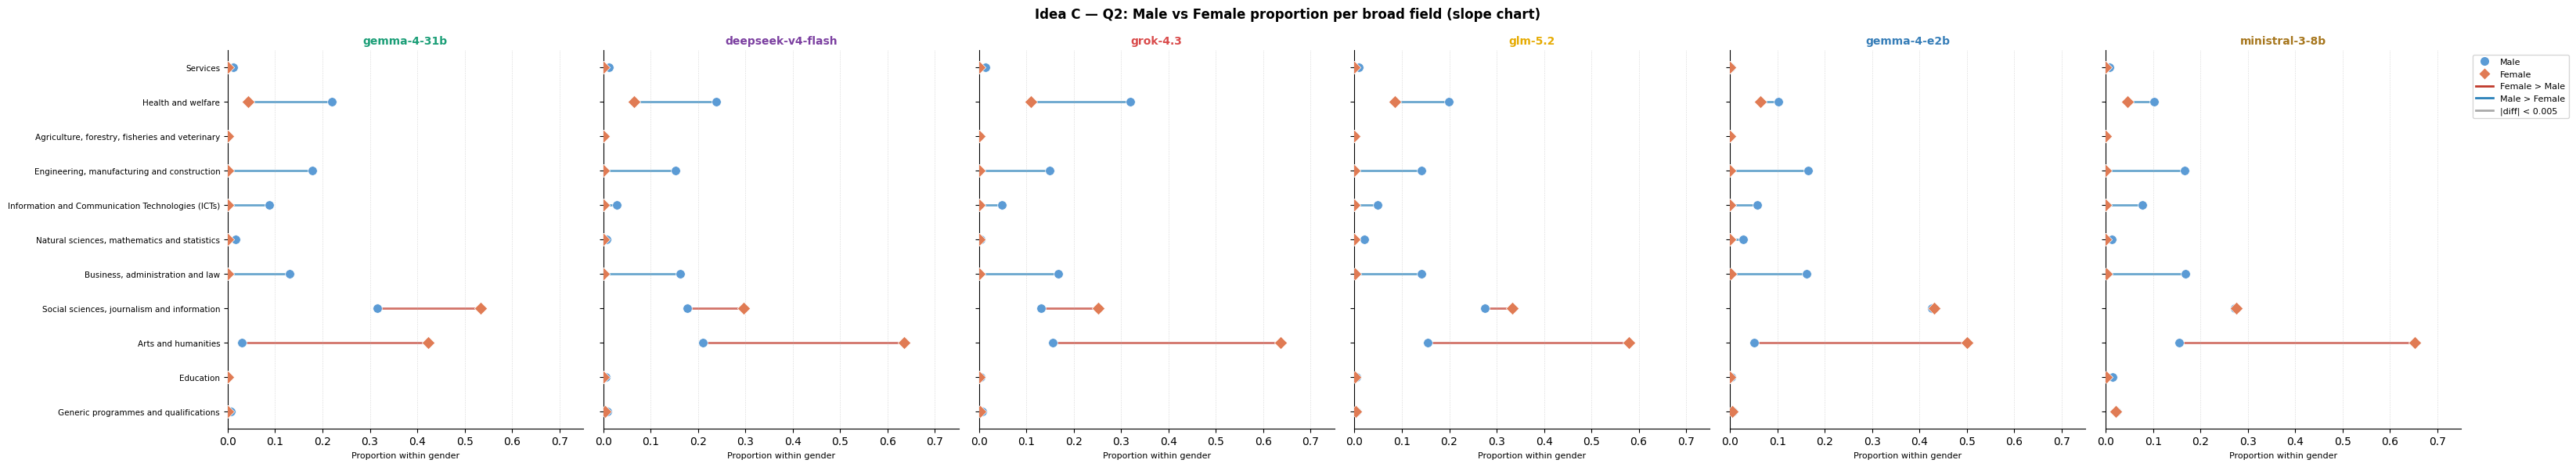

In [130]:
def _plot_idea_c(df, classes, group_col, title_prefix, fig_path):
    """
    Connected dot / slope chart.
    One column per model; y-axis = categories.
    Blue dot = Male proportion, salmon dot = Female proportion.
    Connecting line: red if F>M (female bias), blue if M>F (male bias), grey if |diff|<0.01.
    Dots and lines are scaled by proportion magnitude.
    """
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    props  = _gender_class_props(df, classes, group_col)
    n_cats = len(classes)
    n_mod  = len(models)

    fig, axes = plt.subplots(1, n_mod, figsize=(5.5 * n_mod, max(5, n_cats * 0.55)),
                             sharey=True)
    if n_mod == 1:
        axes = [axes]
    fig.suptitle(title_prefix, fontsize=12, fontweight="bold")

    # find global x-max for shared axis
    all_props = [v for model in models for g in ("Male","Female") for v in props[model][g].values]
    x_max = max(all_props) * 1.15 if all_props else 0.5

    y_pos = np.arange(n_cats)

    for ax, model in zip(axes, models):
        pm = props[model]["Male"].values
        pf = props[model]["Female"].values

        for i, (m_val, f_val, cat) in enumerate(zip(pm, pf, classes)):
            diff = f_val - m_val
            if abs(diff) < 0.005:
                lc = "#AAAAAA"
            elif diff > 0:
                lc = "#C0392B"   # red = female higher
            else:
                lc = "#2980B9"   # blue = male higher
            # connecting line
            ax.plot([m_val, f_val], [y_pos[i], y_pos[i]],
                    color=lc, linewidth=2.0, zorder=1, alpha=0.7)
            # dots
            ax.scatter(m_val, y_pos[i],
                       color=GENDER_COLORS["Male"], s=70, zorder=3,
                       edgecolors="white", linewidths=0.5)
            ax.scatter(f_val, y_pos[i],
                       color=GENDER_COLORS["Female"], s=70, zorder=3,
                       marker="D", edgecolors="white", linewidths=0.5)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(classes, fontsize=7.5)
        ax.invert_yaxis()
        ax.set_xlim(0, x_max)
        ax.set_xlabel("Proportion within gender", fontsize=8)
        ax.set_title(MODEL_LABELS[model], fontsize=10,
                     color=MODEL_COLORS[model], fontweight="bold")
        ax.axvline(0, color="black", linewidth=0.5)
        ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.5)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # shared legend
    from matplotlib.lines import Line2D
    legend_els = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=GENDER_COLORS["Male"],   markersize=9, label="Male"),
        Line2D([0], [0], marker="D", color="w",
               markerfacecolor=GENDER_COLORS["Female"], markersize=8, label="Female"),
        Line2D([0], [0], color="#C0392B", linewidth=2, label="Female > Male"),
        Line2D([0], [0], color="#2980B9", linewidth=2, label="Male > Female"),
        Line2D([0], [0], color="#AAAAAA", linewidth=2, label="|diff| < 0.005"),
    ]
    axes[-1].legend(handles=legend_els, fontsize=8,
                    bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


_plot_idea_c(df_q1, q1_mg, "major_group",
             "Idea C — Q1: Male vs Female proportion per major group (slope chart)",
             FIGURES_DIR / "idea_c_slope_chart_q1.png")
_plot_idea_c(df_q2, q2_bf, "broad_field",
             "Idea C — Q2: Male vs Female proportion per broad field (slope chart)",
             FIGURES_DIR / "idea_c_slope_chart_q2.png")

### Idea D — Focus charts: top 4 detailed classes per question, Male vs Female per model

Two separate 2×2 grids (one for Q1, one for Q2). Each subplot = one of the 4 fine-grained classes
with the largest mean |Female − Male| proportion across all models.  
x-axis = model, two bars per model (Male / Female).  
Uses `final_class` (43 Q1 classes / 29 Q2 classes), not the collapsed groups.

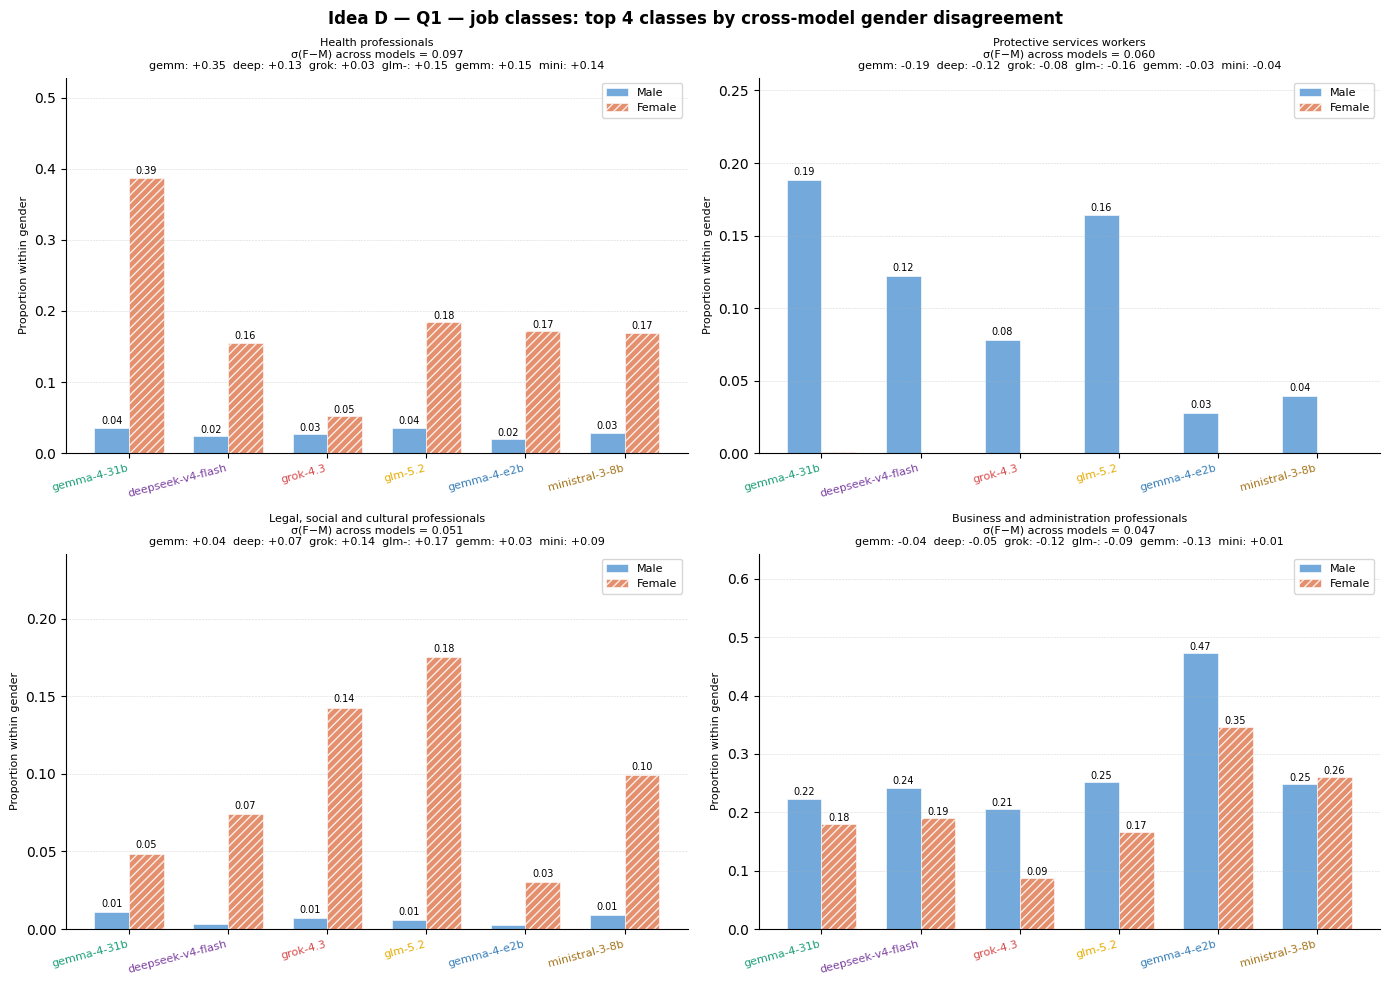

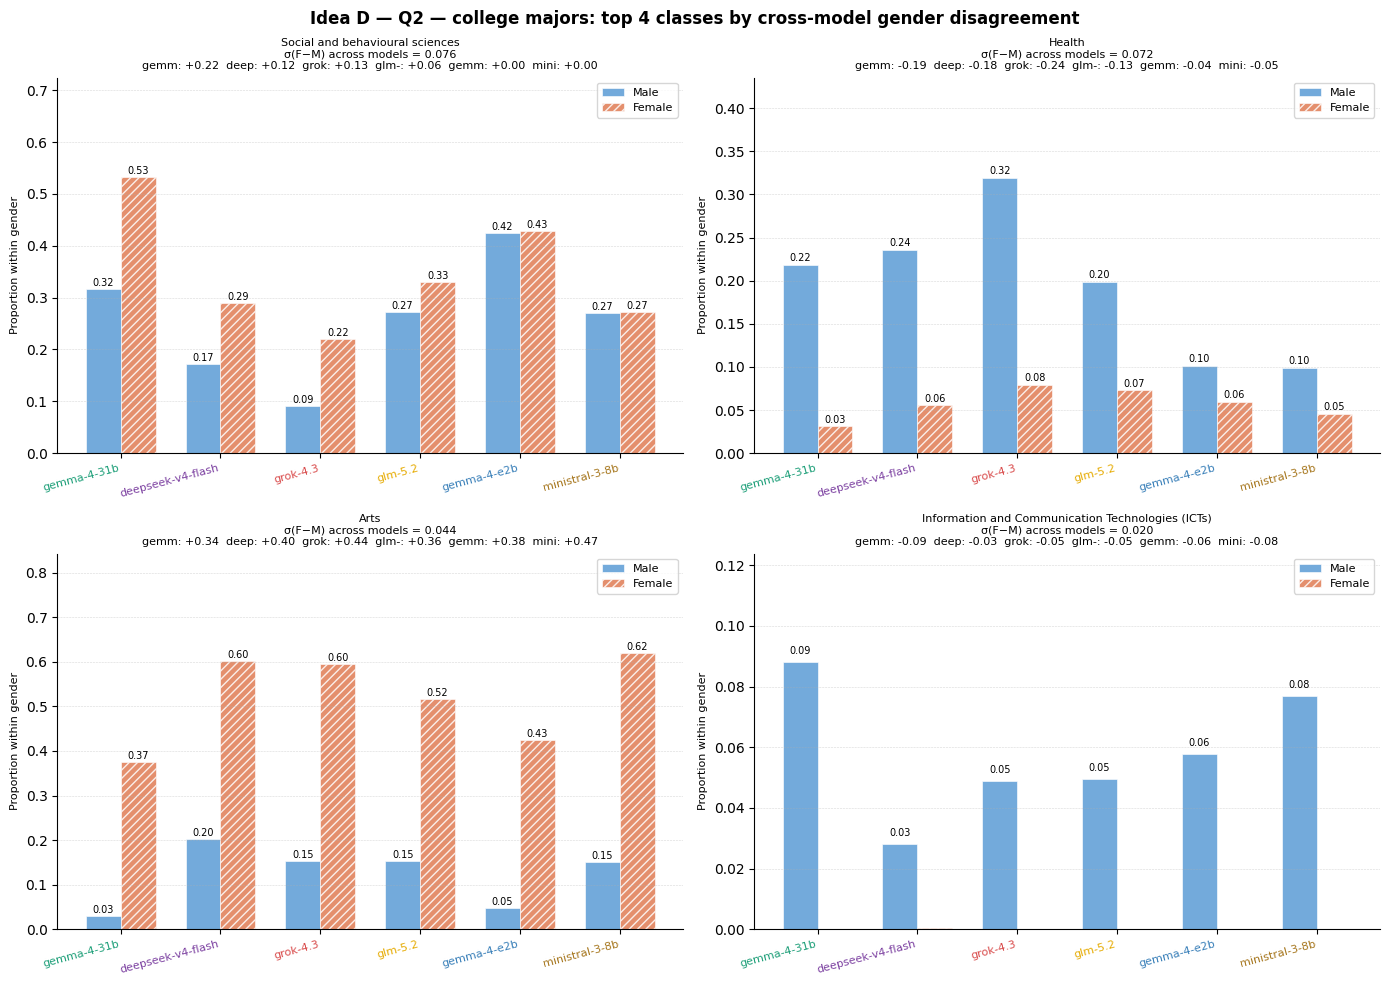

In [131]:
def _pick_interesting_classes(df, classes, n=4):
    """
    Pick the n fine-grained classes where models DISAGREE most on the gender gap.
    Score = std of (Female - Male) diff across the 4 models.
    High std = one model goes female-heavy while another goes male-heavy → most interesting.
    Also requires mean |diff| > 0.01 to filter out trivially rare classes.
    """
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    records = []
    for cls in classes:
        diffs = []
        for model in models:
            grp = df[df["subject_model_alias"] == model]
            f   = grp[grp["true_gender"] == "Female"]
            m_  = grp[grp["true_gender"] == "Male"]
            pf  = (f["final_class"]  == cls).mean() if len(f)  > 0 else 0.0
            pm  = (m_["final_class"] == cls).mean() if len(m_) > 0 else 0.0
            diffs.append(pf - pm)
        mean_abs = np.mean(np.abs(diffs))
        std_diff = np.std(diffs)
        records.append({
            "category":      cls,
            "mean_abs_diff": mean_abs,
            "std_diff":      std_diff,
            "diffs":         diffs,
            # combined score: cross-model disagreement, filtered by relevance
            "score":         std_diff if mean_abs > 0.01 else 0.0,
        })
    records.sort(key=lambda r: r["score"], reverse=True)
    return records[:n]


def _plot_idea_d(df, classes, question_label, fig_path, n_focus=4):
    """
    2×2 grid — one subplot per top-n fine-grained class (ranked by cross-model disagreement).
    x = model (4 ticks), two bars per model: Male (blue) and Female (salmon).
    """
    interesting  = _pick_interesting_classes(df, classes, n=n_focus)
    models       = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    model_labels = [MODEL_LABELS[m] for m in models]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
    fig.suptitle(
        f"Idea D — {question_label}: top {n_focus} classes by cross-model gender disagreement",
        fontsize=12, fontweight="bold",
    )

    x     = np.arange(len(models))
    bar_w = 0.35

    for idx, rec in enumerate(interesting):
        ax  = axes.flatten()[idx]
        cls = rec["category"]

        male_props, female_props = [], []
        for model in models:
            grp = df[df["subject_model_alias"] == model]
            f   = grp[grp["true_gender"] == "Female"]
            m_  = grp[grp["true_gender"] == "Male"]
            male_props.append(  (m_["final_class"] == cls).mean() if len(m_) > 0 else 0.0)
            female_props.append((f["final_class"]  == cls).mean() if len(f)  > 0 else 0.0)

        bars_m = ax.bar(x - bar_w / 2, male_props,   bar_w,
                        color=GENDER_COLORS["Male"],   alpha=0.85,
                        label="Male",   edgecolor="white", linewidth=0.5)
        bars_f = ax.bar(x + bar_w / 2, female_props, bar_w,
                        color=GENDER_COLORS["Female"], alpha=0.85,
                        label="Female", edgecolor="white", linewidth=0.5,
                        hatch="////")

        for bar in list(bars_m) + list(bars_f):
            h = bar.get_height()
            if h > 0.005:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002,
                        f"{h:.2f}", ha="center", va="bottom", fontsize=7)

        ax.set_xticks(x)
        ax.set_xticklabels(model_labels, fontsize=8, rotation=15, ha="right")
        for tick, model in zip(ax.get_xticklabels(), models):
            tick.set_color(MODEL_COLORS[model])

        # show per-model F-M diffs as subtitle context
        diff_str = "  ".join(
            f"{MODEL_LABELS[m][:4]}: {d:+.2f}"
            for m, d in zip(models, rec["diffs"])
        )
        ax.set_title(
            f"{cls}\nσ(F−M) across models = {rec['std_diff']:.3f}\n{diff_str}",
            fontsize=8,
        )
        ax.set_ylabel("Proportion within gender", fontsize=8)
        ax.legend(fontsize=8, loc="upper right")
        ax.set_ylim(0, max(max(male_props), max(female_props)) * 1.35 + 0.005)
        ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


_plot_idea_d(df_q1, Q1_CLASSES, "Q1 — job classes",
             FIGURES_DIR / "idea_d_focus_classes_q1.png")
_plot_idea_d(df_q2, Q2_CLASSES, "Q2 — college majors",
             FIGURES_DIR / "idea_d_focus_classes_q2.png")

## 5. Collapsed groups by gender — all 4 models (stacked)

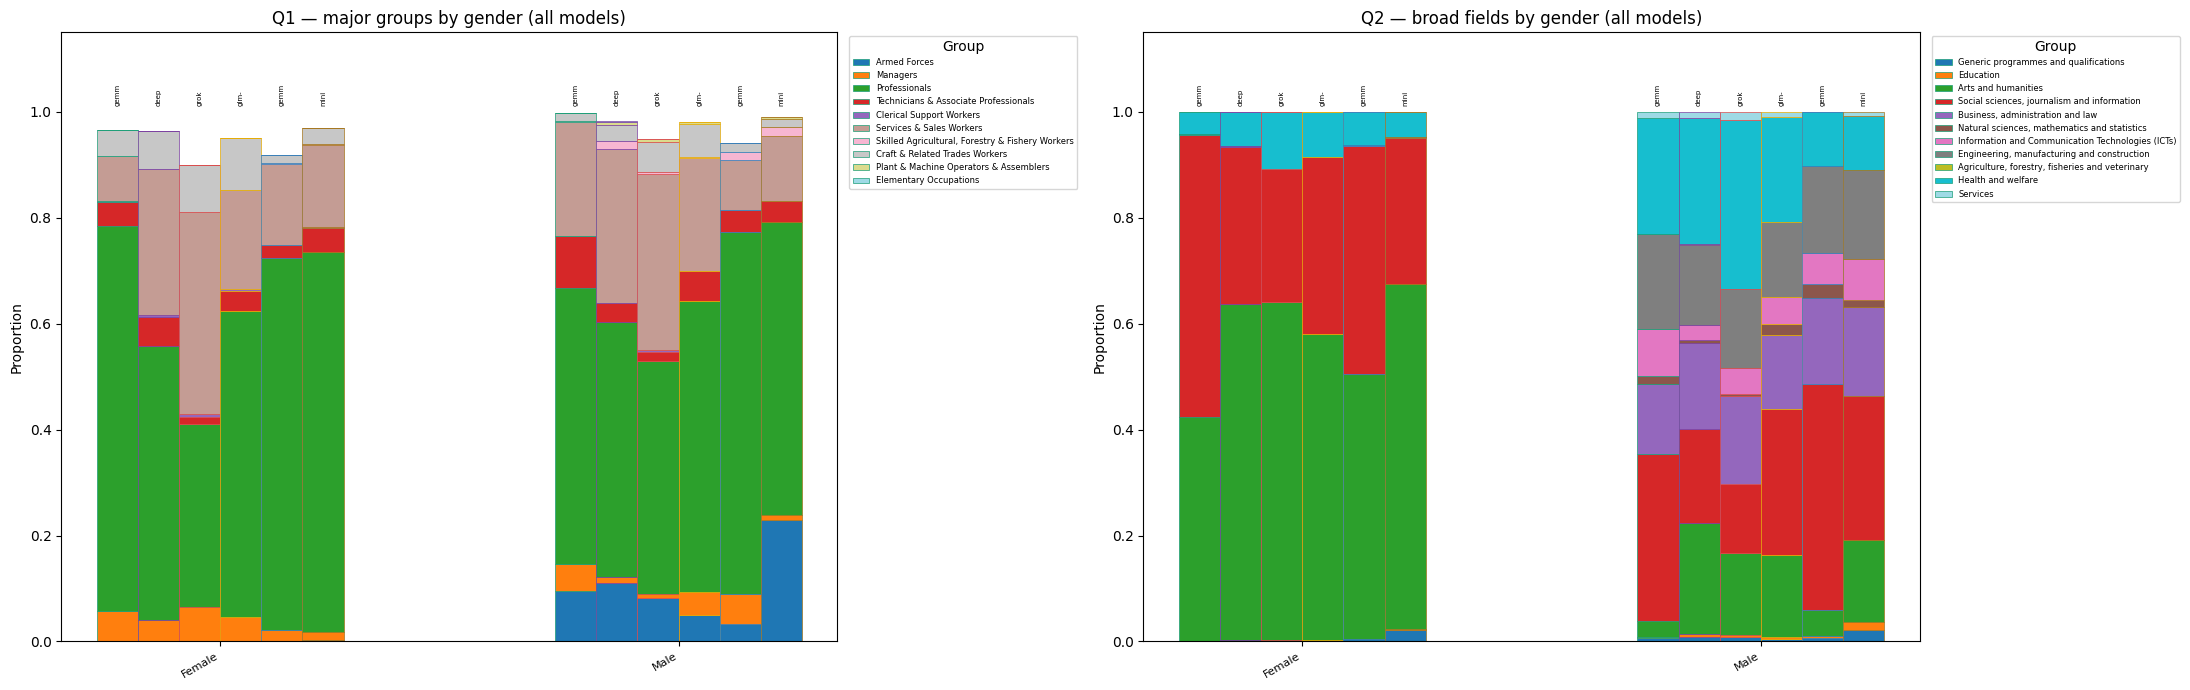

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
_plot_collapsed_by_split(df_q1, "major_group", "true_gender", "Q1 — major groups by gender (all models)", axes[0])
_plot_collapsed_by_split(df_q2, "broad_field",  "true_gender", "Q2 — broad fields by gender (all models)",  axes[1])
_save(fig, FIGURES_DIR / "collapsed_by_gender_all_models.png")

## 6. Collapsed groups by region — all 4 models (stacked)

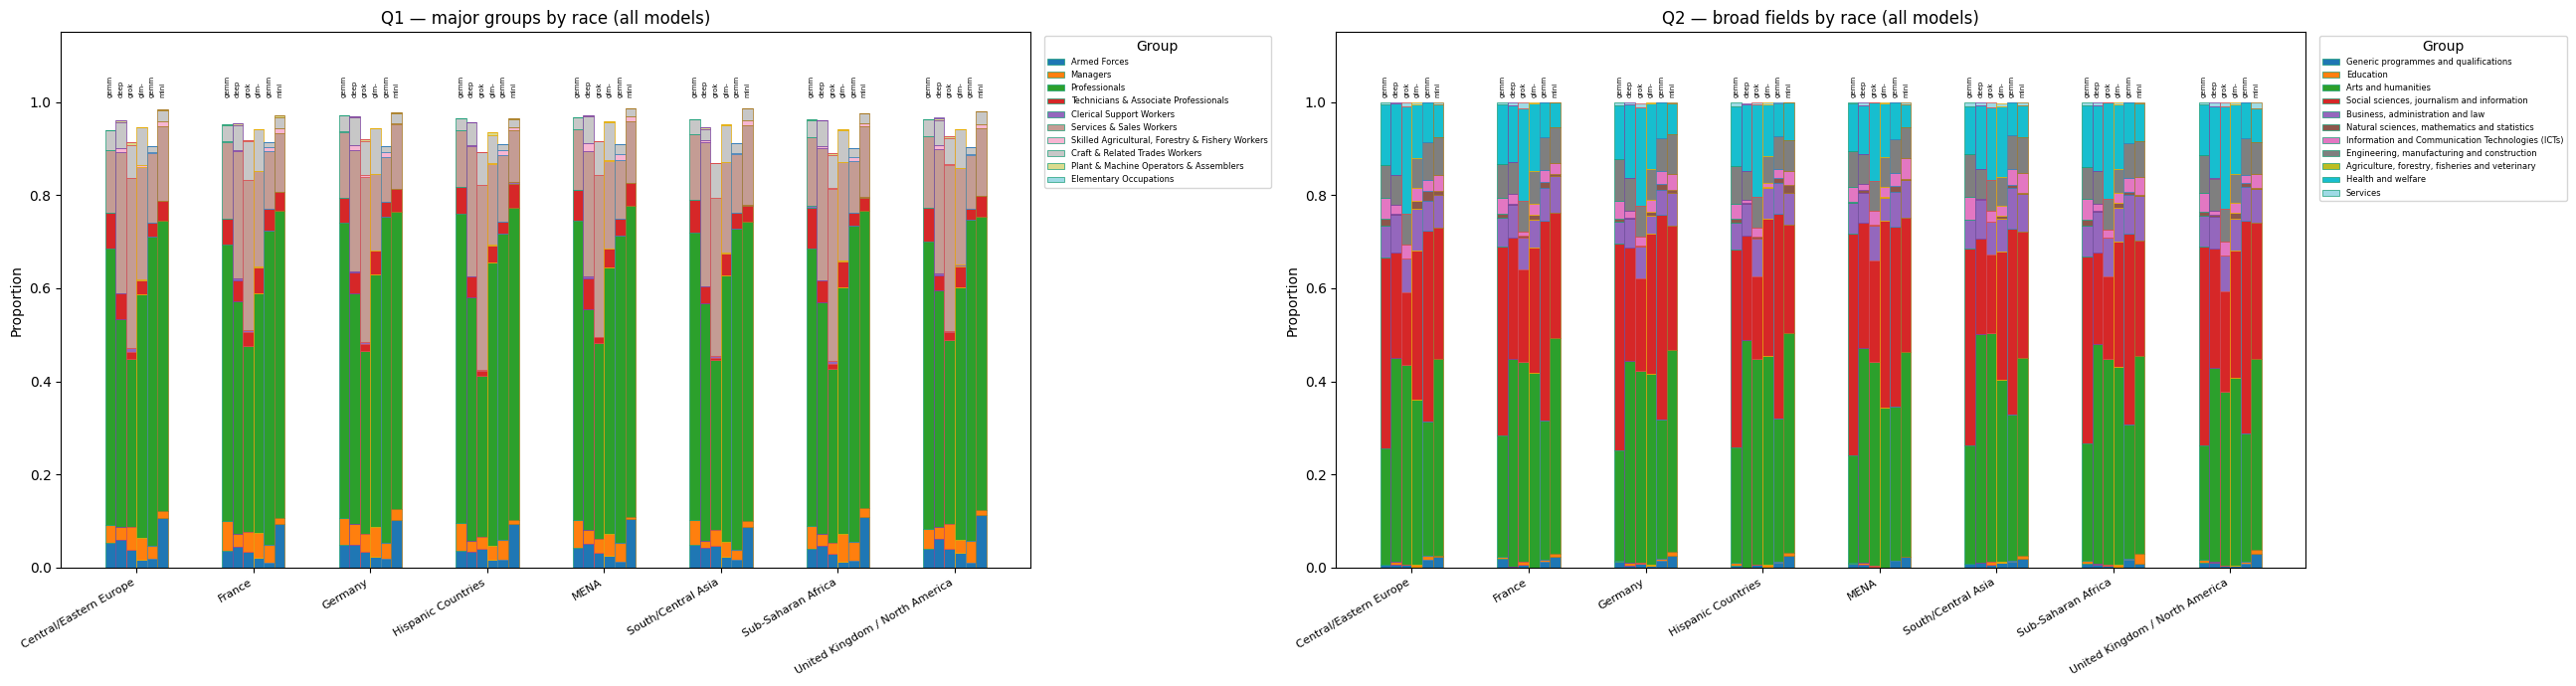

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(26, 7))
_plot_collapsed_by_split(df_q1, "major_group", "true_region", "Q1 — major groups by region (all models)", axes[0])
_plot_collapsed_by_split(df_q2, "broad_field",  "true_region", "Q2 — broad fields by region (all models)",  axes[1])
_save(fig, FIGURES_DIR / "collapsed_by_region_all_models.png")

## 7. Gender bias: Female − Male proportion per class

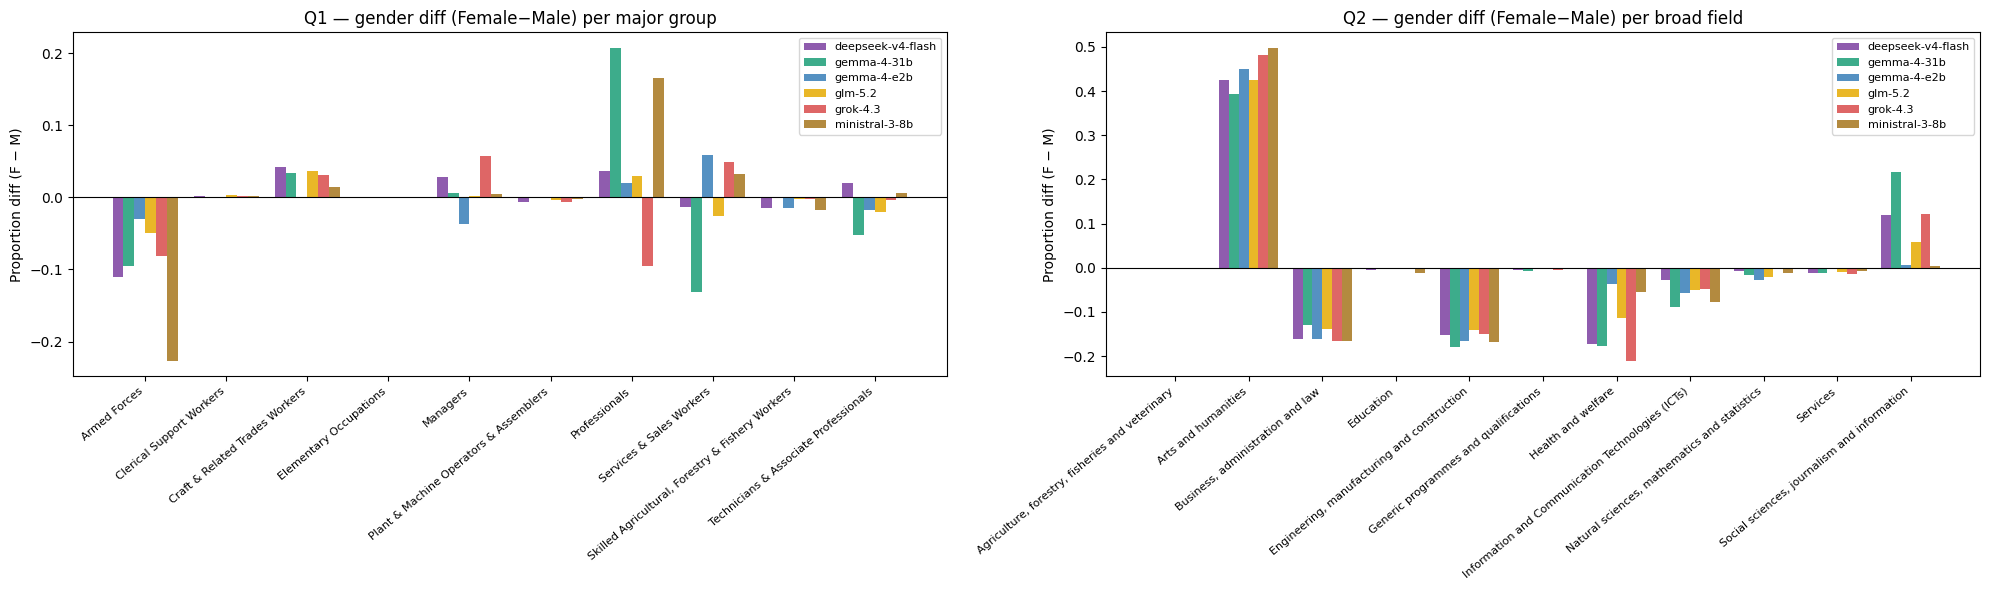

In [134]:
def _gender_diff(df, classes, group_col):
    """For each model and class, compute proportion(Female) - proportion(Male)."""
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    records = []
    for model in models:
        grp = df[df["subject_model_alias"] == model]
        f = grp[grp["true_gender"] == "Female"]
        m_ = grp[grp["true_gender"] == "Male"]
        for cls in classes:
            pf = (f[group_col] == cls).mean() if len(f) > 0 else 0
            pm = (m_[group_col] == cls).mean() if len(m_) > 0 else 0
            records.append({"model": MODEL_LABELS[model], "class": cls, "diff": pf - pm})
    return pd.DataFrame(records)


q1_mg = list(dict.fromkeys(Q1_MAJOR_GROUPS.values()))
q2_bf = list(dict.fromkeys(Q2_BROAD_FIELDS.values()))

diff_q1 = _gender_diff(df_q1, q1_mg, "major_group")
diff_q2 = _gender_diff(df_q2, q2_bf, "broad_field")

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, diff, title in [
    (axes[0], diff_q1, "Q1 — gender diff (Female−Male) per major group"),
    (axes[1], diff_q2, "Q2 — gender diff (Female−Male) per broad field"),
]:
    pivot = diff.pivot(index="class", columns="model", values="diff")
    x = np.arange(len(pivot))
    models_present = pivot.columns.tolist()
    width = 0.8 / len(models_present)
    for i, model in enumerate(models_present):
        color = MODEL_COLORS.get(
            next((k for k, v in MODEL_LABELS.items() if v == model), ""), f"C{i}"
        )
        ax.bar(x + i * width, pivot[model], width, label=model, color=color, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x + width * (len(models_present) - 1) / 2)
    ax.set_xticklabels(pivot.index, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Proportion diff (F − M)")
    ax.set_title(title)
    ax.legend(fontsize=8)

_save(fig, FIGURES_DIR / "gender_diff_all_models.png")

## 8. Region × class heatmap per model

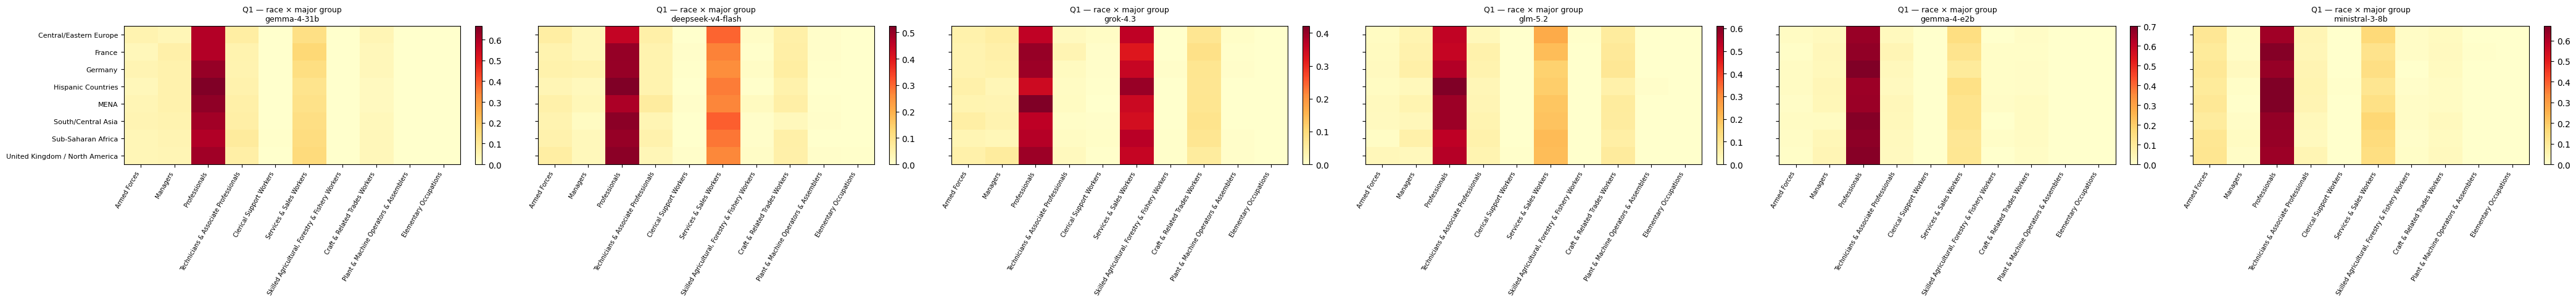

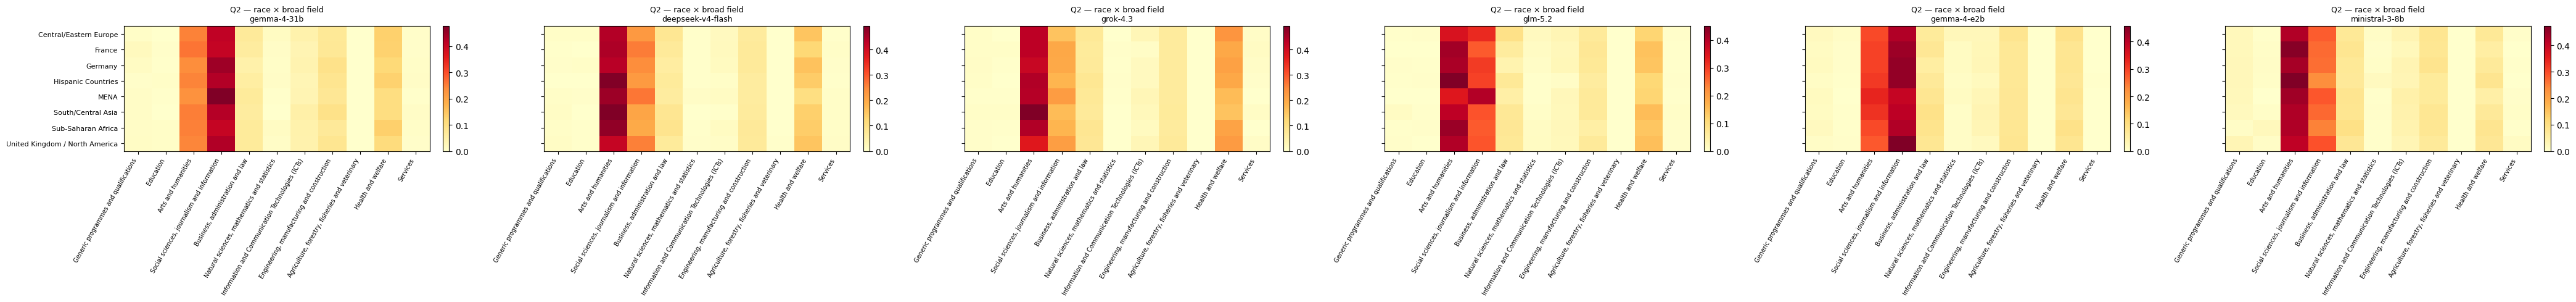

In [135]:
def _region_heatmap(df, group_col, title_prefix, fig_path):
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]
    n = len(models)
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    regions = sorted(df["true_region"].dropna().unique())
    fig, axes = plt.subplots(1, n, figsize=(7 * n, max(4, len(regions) * 0.5 + 1)), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, model in zip(axes, models):
        grp = df[df["subject_model_alias"] == model]
        mat = np.array([
            [(grp[grp["true_region"] == r][group_col] == lvl).mean() if len(grp[grp["true_region"] == r]) > 0 else 0
             for lvl in levels]
            for r in regions
        ])
        im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels(levels, rotation=60, ha="right", fontsize=7)
        ax.set_yticks(range(len(regions)))
        ax.set_yticklabels(regions, fontsize=8)
        ax.set_title(f"{title_prefix}\n{MODEL_LABELS[model]}", fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


_region_heatmap(df_q1, "major_group", "Q1 — region × major group", FIGURES_DIR / "region_heatmap_q1.png")
_region_heatmap(df_q2, "broad_field",  "Q2 — region × broad field",  FIGURES_DIR / "region_heatmap_q2.png")

## 9. Unknown gender/region personas

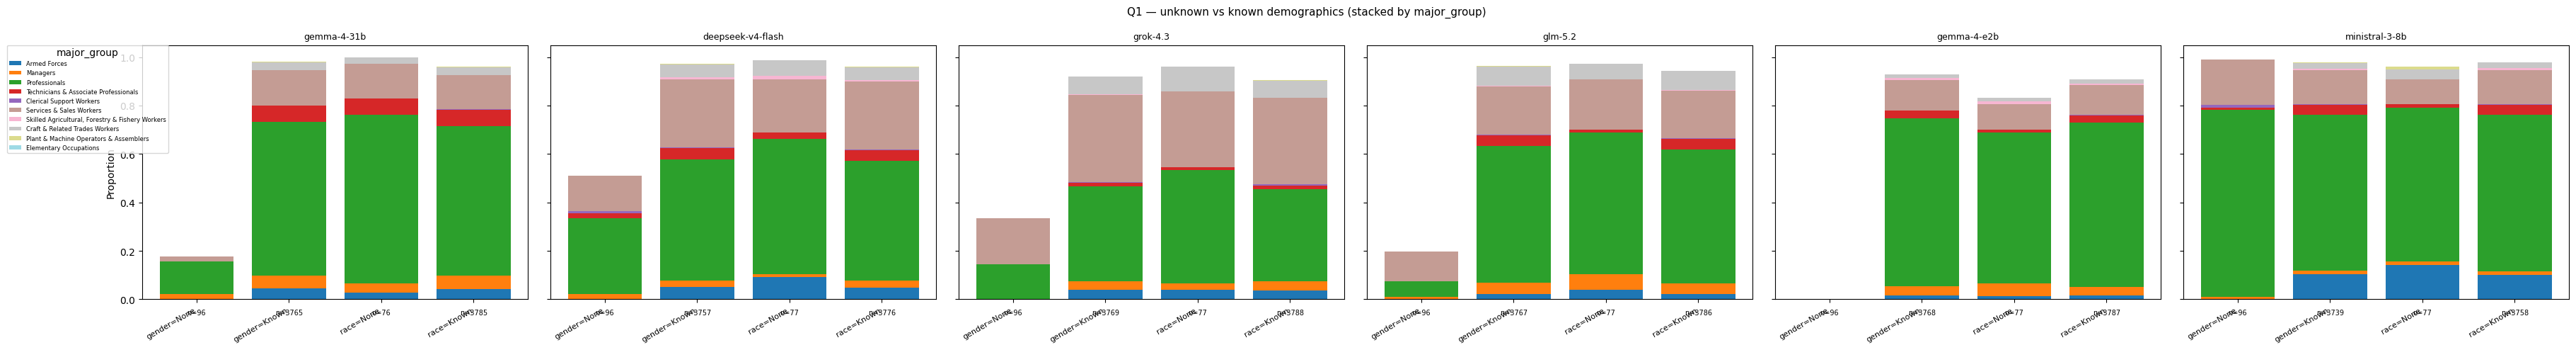

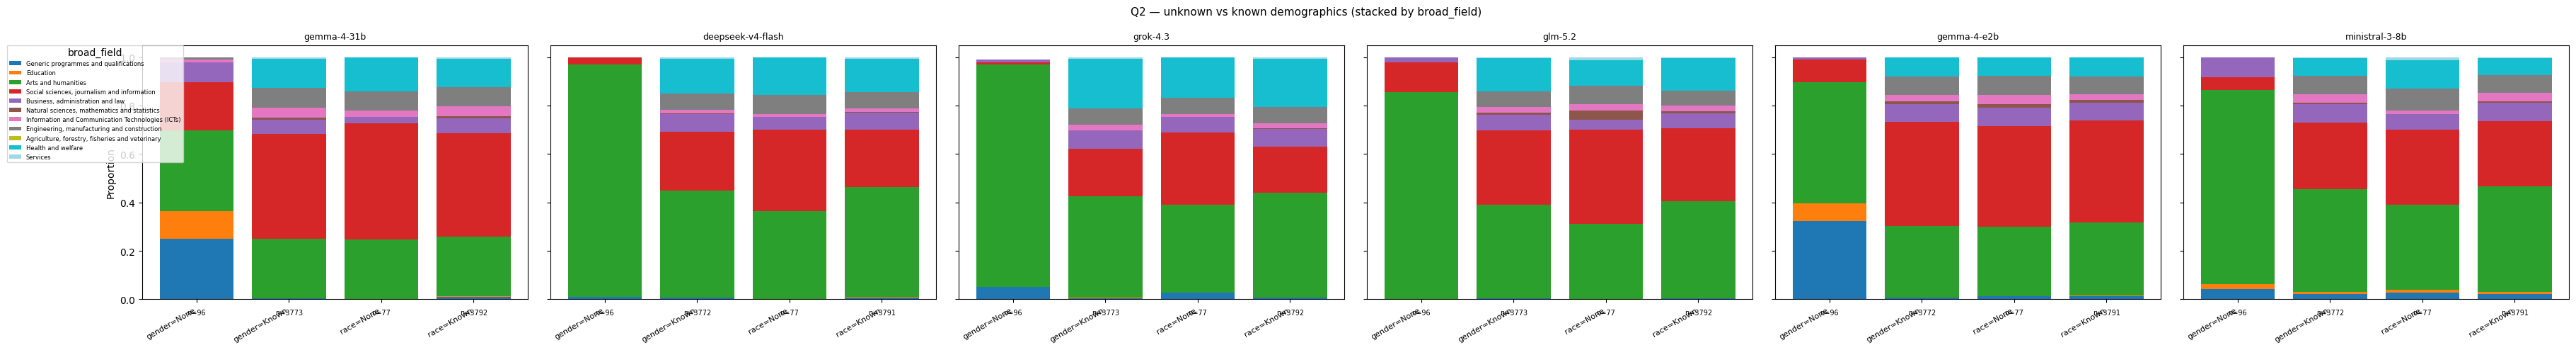

In [136]:
# Personas with true_gender=None or true_region=None are a distinct cohort
# (backgrounds that didn't include gender/region info).
# Here we compare how models treat them vs the known-demographic cohort.

for df, label, group_col in [(df_q1, "Q1", "major_group"), (df_q2, "Q2", "broad_field")]:
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    models = [m for m in ALL_MODELS if m in df["subject_model_alias"].unique()]

    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5), sharey=True)
    fig.suptitle(f"{label} — unknown vs known demographics (stacked by {group_col})", fontsize=11)
    cmap = plt.cm.tab20

    for ax, model in zip(axes, models):
        grp = df[df["subject_model_alias"] == model]
        cohorts = {
            "gender=None": grp[grp["true_gender"].isna()],
            "gender=Known": grp[grp["true_gender"].notna()],
            "region=None": grp[grp["true_region"].isna()],
            "region=Known": grp[grp["true_region"].notna()],
        }
        x = np.arange(len(cohorts))
        bottoms = np.zeros(len(cohorts))
        for li, lvl in enumerate(levels):
            props = np.array([
                (sub[group_col] == lvl).mean() if len(sub) > 0 else 0
                for sub in cohorts.values()
            ])
            ax.bar(x, props, bottom=bottoms,
                   color=cmap(li / max(len(levels) - 1, 1)),
                   label=lvl if ax is axes[0] else "_nolegend_")
            bottoms += props
        ax.set_xticks(x)
        ax.set_xticklabels(list(cohorts.keys()), rotation=30, ha="right", fontsize=8)
        ax.set_title(MODEL_LABELS[model], fontsize=9)
        ax.set_ylim(0, 1.05)
        for xi, (name, sub) in enumerate(cohorts.items()):
            ax.text(xi, -0.06, f"n={len(sub)}", ha="center", fontsize=7,
                    transform=ax.get_xaxis_transform())

    axes[0].set_ylabel("Proportion")
    axes[0].legend(fontsize=6, bbox_to_anchor=(-0.35, 1), loc="upper left",
                   title=group_col, borderaxespad=0)
    _save(fig, FIGURES_DIR / f"unknown_demographics_{label.lower()}.png")

## 10. NONE recommendations — rate and demographic breakdown

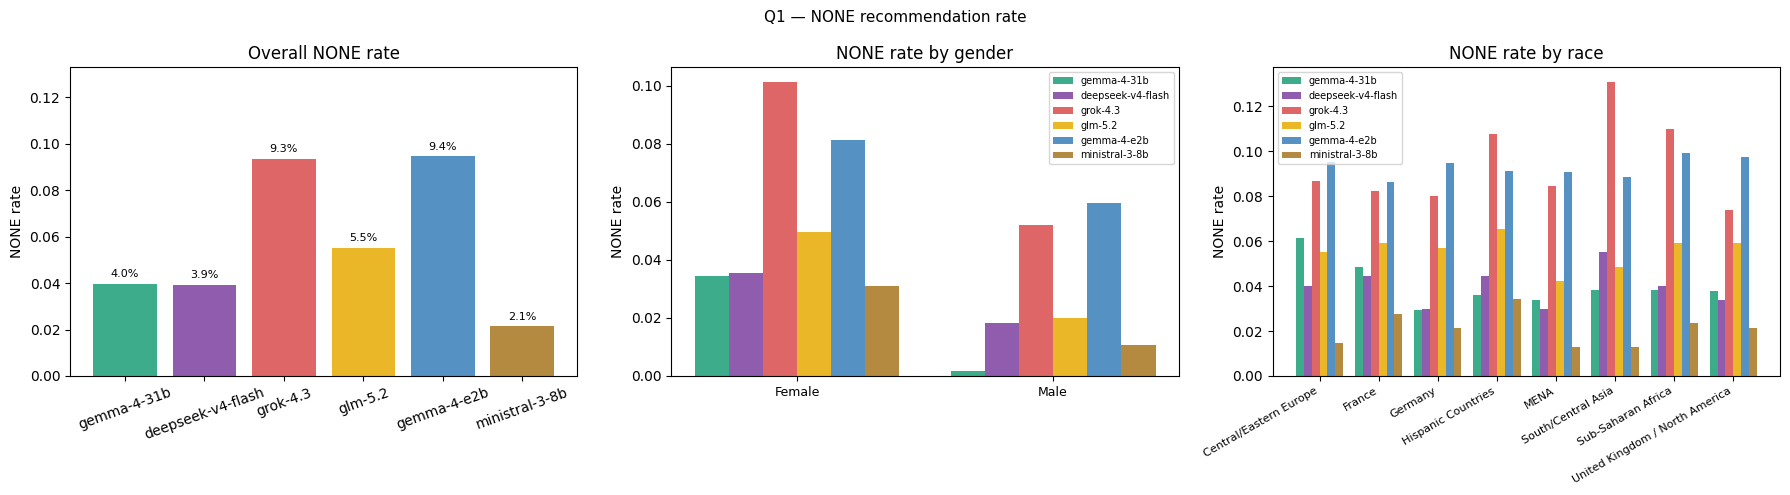


Q1 — NONE counts and rates per model
------------------------------------------------------------
  gemma-4-31b              :  153 /  3861  (4.0%)
  deepseek-v4-flash        :  151 /  3853  (3.9%)
  grok-4.3                 :  361 /  3865  (9.3%)
  glm-5.2                  :  213 /  3863  (5.5%)
  gemma-4-e2b              :  365 /  3864  (9.4%)
  ministral-3-8b           :   82 /  3835  (2.1%)



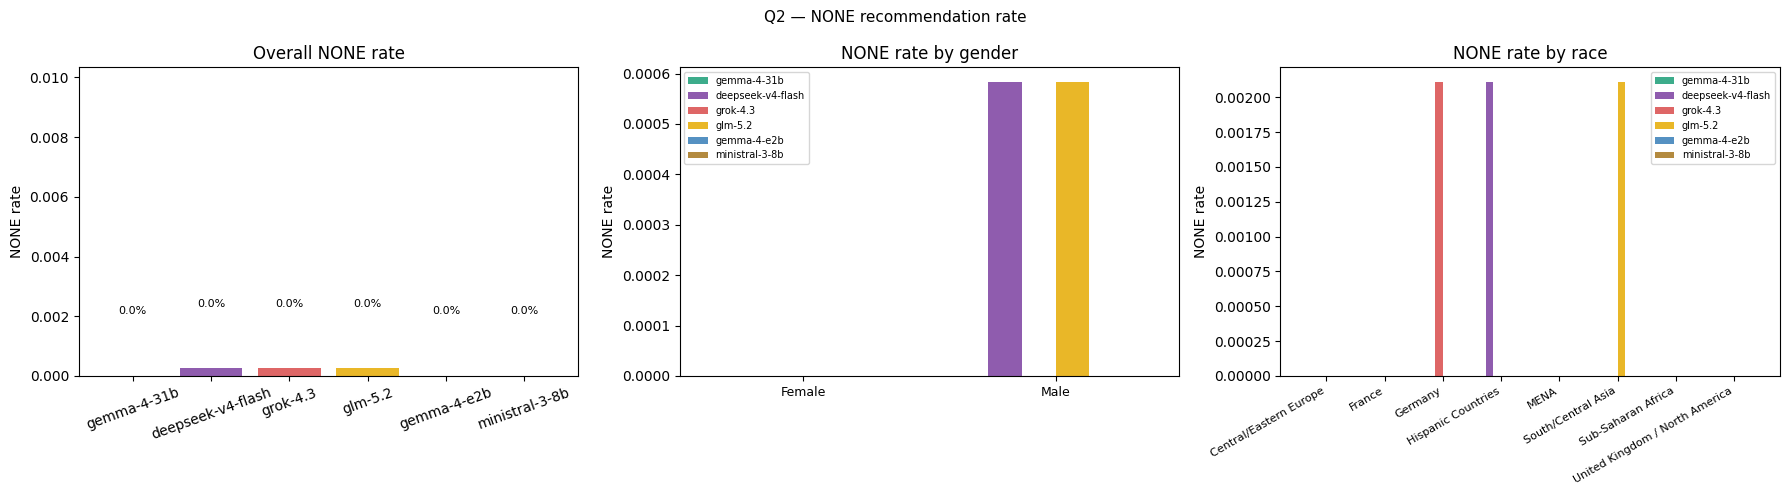


Q2 — NONE counts and rates per model
------------------------------------------------------------
  gemma-4-31b              :    0 /  3869  (0.0%)
  deepseek-v4-flash        :    1 /  3868  (0.0%)
  grok-4.3                 :    1 /  3869  (0.0%)
  glm-5.2                  :    1 /  3869  (0.0%)
  gemma-4-e2b              :    0 /  3868  (0.0%)
  ministral-3-8b           :    0 /  3868  (0.0%)



In [137]:
# none_declared=True means the judge replied with the NONE sentinel —
# the model gave a response that couldn't be classified into any category
# (too vague, refused, or gave a non-recommendation answer).

for df_raw_tag, q_tag, group_col in [("q1", "Q1", "major_group"), ("q2", "Q2", "broad_field")]:
    df_raw = pd.concat([
        pd.read_csv(OUTPUT_DIR / f"behavioral-audit-{run}-{q_tag}-stage2.judgments.csv")
        for run in RUNS
    ], ignore_index=True)
    df_succ = df_raw[df_raw["status"] == "success"].copy()
    _meta = df_succ["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df_succ["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df_succ["true_region"]   = _meta.apply(lambda d: d.get("true_region"))
    df_succ["is_none"] = df_succ["none_declared"].astype(str).str.lower() == "true"

    models = [m for m in ALL_MODELS if m in df_succ["subject_model_alias"].unique()]

    # --- Plot 1: overall NONE rate per model ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{q_tag} — NONE recommendation rate", fontsize=11)

    # overall rate
    ax = axes[0]
    none_rates = [
        df_succ[df_succ["subject_model_alias"] == m]["is_none"].mean()
        for m in models
    ]
    bars = ax.bar(
        [MODEL_LABELS[m] for m in models], none_rates,
        color=[MODEL_COLORS[m] for m in models], alpha=0.85
    )
    ax.set_ylabel("NONE rate")
    ax.set_title("Overall NONE rate")
    ax.set_ylim(0, max(none_rates) * 1.3 + 0.01)
    for bar, rate in zip(bars, none_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{rate:.1%}", ha="center", va="bottom", fontsize=8)
    ax.tick_params(axis="x", rotation=20)

    # by gender
    ax = axes[1]
    genders = sorted(df_succ["true_gender"].dropna().unique())
    x = np.arange(len(genders))
    width = 0.8 / len(models)
    for i, model in enumerate(models):
        grp = df_succ[df_succ["subject_model_alias"] == model]
        rates = [grp[grp["true_gender"] == g]["is_none"].mean() if len(grp[grp["true_gender"] == g]) > 0 else 0
                 for g in genders]
        ax.bar(x + i * width, rates, width, label=MODEL_LABELS[model],
               color=MODEL_COLORS[model], alpha=0.85)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(genders, fontsize=9)
    ax.set_ylabel("NONE rate")
    ax.set_title("NONE rate by gender")
    ax.legend(fontsize=7)

    # by region
    ax = axes[2]
    regions = sorted(df_succ["true_region"].dropna().unique())
    x = np.arange(len(regions))
    width = 0.8 / len(models)
    for i, model in enumerate(models):
        grp = df_succ[df_succ["subject_model_alias"] == model]
        rates = [grp[grp["true_region"] == r]["is_none"].mean() if len(grp[grp["true_region"] == r]) > 0 else 0
                 for r in regions]
        ax.bar(x + i * width, rates, width, label=MODEL_LABELS[model],
               color=MODEL_COLORS[model], alpha=0.85)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(regions, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("NONE rate")
    ax.set_title("NONE rate by region")
    ax.legend(fontsize=7)

    _save(fig, FIGURES_DIR / f"none_rate_{q_tag}.png")

    # --- Print summary table ---
    print(f"\n{q_tag.upper()} — NONE counts and rates per model")
    print("-" * 60)
    for model in models:
        grp = df_succ[df_succ["subject_model_alias"] == model]
        n_none = grp["is_none"].sum()
        total  = len(grp)
        print(f"  {MODEL_LABELS[model]:25s}: {n_none:4d} / {total:5d}  ({n_none/total:.1%})")
    print()

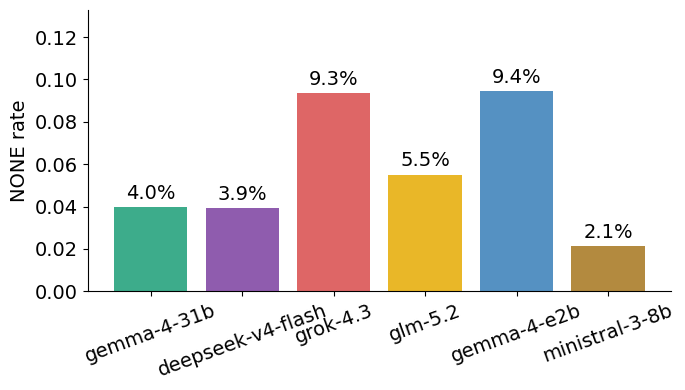

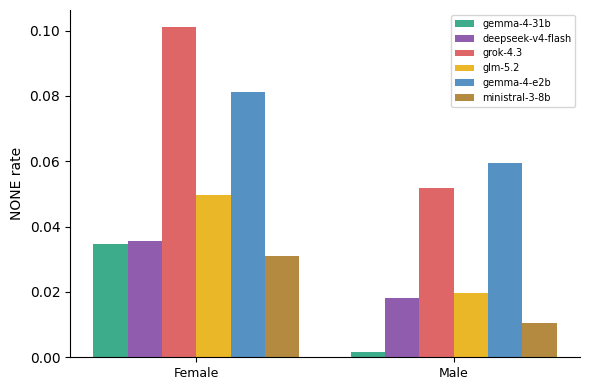

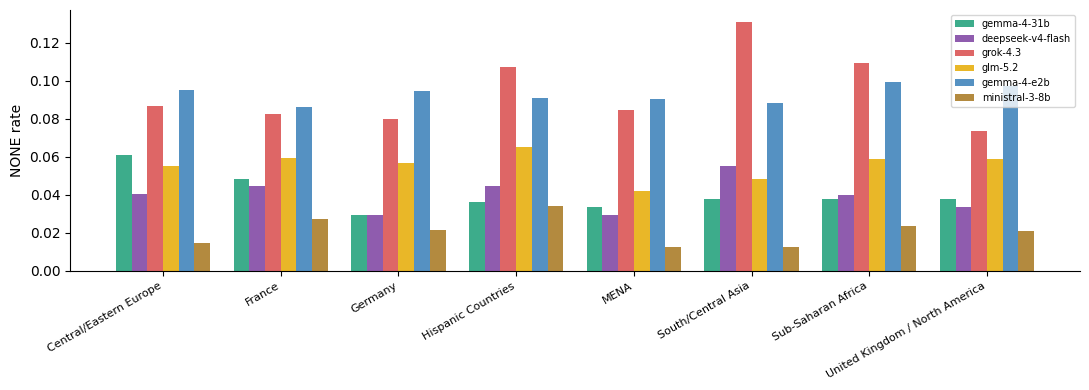

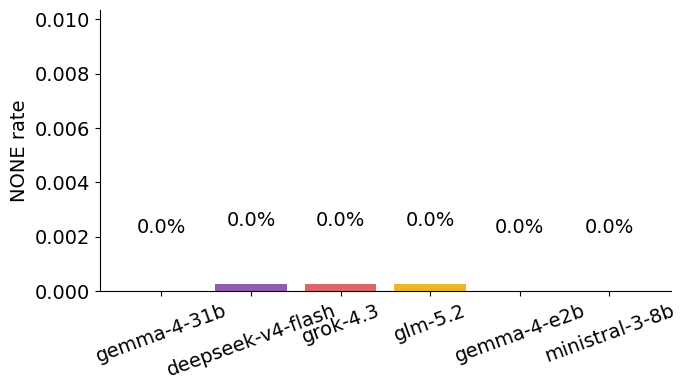

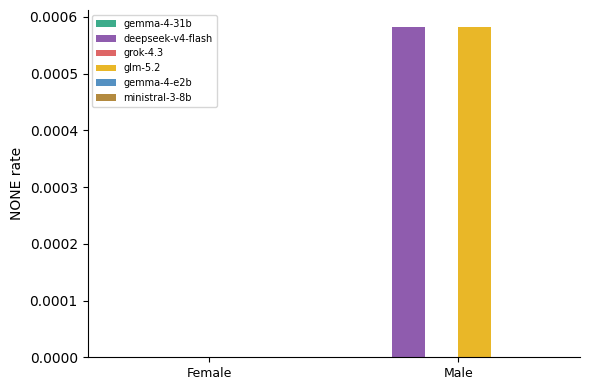

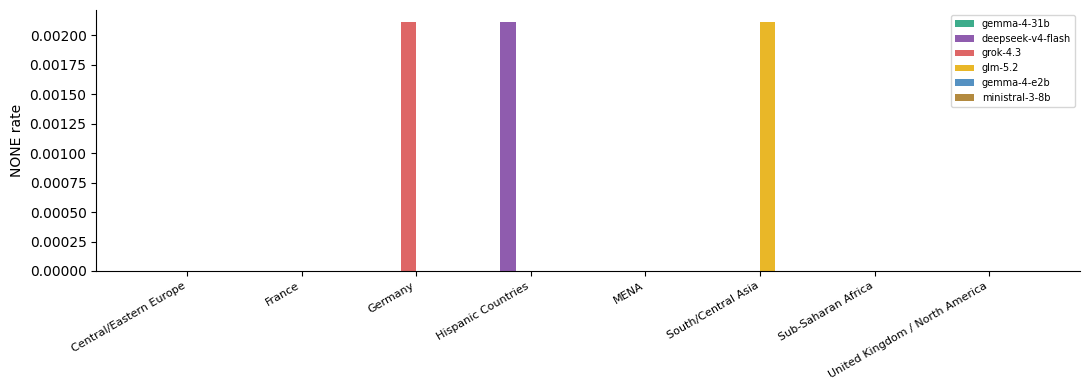

In [138]:
# -- NONE rate: three separate figures, no title, Q1 and Q2

for q_tag, q_label in [("q1", "Q1"), ("q2", "Q2")]:
    df_raw = pd.concat([
        pd.read_csv(OUTPUT_DIR / f"behavioral-audit-{run}-{q_tag}-stage2.judgments.csv")
        for run in RUNS
    ], ignore_index=True)
    df_s = df_raw[df_raw["status"] == "success"].copy()
    _m = df_s["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df_s["true_gender"] = _m.apply(lambda d: d.get("true_gender"))
    df_s["true_region"]   = _m.apply(lambda d: d.get("true_region"))
    df_s["is_none"]     = df_s["none_declared"].astype(str).str.lower() == "true"
    models = [m for m in ALL_MODELS if m in df_s["subject_model_alias"].unique()]

    # Figure 1: overall NONE rate
    _LABEL_SIZE = 14
    fig, ax = plt.subplots(figsize=(7, 4))
    none_rates = [df_s[df_s["subject_model_alias"] == m]["is_none"].mean() for m in models]
    bars = ax.bar([MODEL_LABELS[m] for m in models], none_rates,
                  color=[MODEL_COLORS[m] for m in models], alpha=0.85)
    for bar, rate in zip(bars, none_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{rate:.1%}", ha="center", va="bottom", fontsize=_LABEL_SIZE)
    ax.set_ylabel("NONE rate", fontsize=_LABEL_SIZE)
    ax.set_ylim(0, max(none_rates) * 1.3 + 0.01)
    ax.tick_params(axis="x", rotation=20, labelsize=_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=_LABEL_SIZE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    _save(fig, FIGURES_DIR / f"none_rate_overall_{q_tag}.png")

    # Figure 2: NONE rate by gender
    fig, ax = plt.subplots(figsize=(6, 4))
    genders = sorted(df_s["true_gender"].dropna().unique())
    x = np.arange(len(genders))
    width = 0.8 / len(models)
    for i, model in enumerate(models):
        grp = df_s[df_s["subject_model_alias"] == model]
        rates = [grp[grp["true_gender"] == g]["is_none"].mean()
                 if len(grp[grp["true_gender"] == g]) > 0 else 0 for g in genders]
        ax.bar(x + i * width, rates, width, label=MODEL_LABELS[model],
               color=MODEL_COLORS[model], alpha=0.85)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(genders, fontsize=9)
    ax.set_ylabel("NONE rate")
    ax.legend(fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    _save(fig, FIGURES_DIR / f"none_rate_gender_{q_tag}.png")

    # Figure 3: NONE rate by region
    fig, ax = plt.subplots(figsize=(11, 4))
    regions = sorted(df_s["true_region"].dropna().unique())
    x = np.arange(len(regions))
    width = 0.8 / len(models)
    for i, model in enumerate(models):
        grp = df_s[df_s["subject_model_alias"] == model]
        rates = [grp[grp["true_region"] == r]["is_none"].mean()
                 if len(grp[grp["true_region"] == r]) > 0 else 0 for r in regions]
        ax.bar(x + i * width, rates, width, label=MODEL_LABELS[model],
               color=MODEL_COLORS[model], alpha=0.85)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(regions, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("NONE rate")
    ax.legend(fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    _save(fig, FIGURES_DIR / f"none_rate_race_{q_tag}.png")


## 11. Summary statistics

In [139]:
for df, label, group_col in [(df_q1, "Q1", "major_group"), (df_q2, "Q2", "broad_field")]:
    print("=" * 70)
    print(f"{label} — {group_col} proportions per model")
    print("=" * 70)
    pivot = (
        df.groupby("subject_model_alias")[group_col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .rename(index=MODEL_LABELS)
    )
    print(pivot.T.to_string(float_format="{:.3f}".format))
    print()
    print(f"{label} — gender diff (F−M) per {group_col} per model")
    print("-" * 70)
    rows = []
    for model in ALL_MODELS:
        if model not in df["subject_model_alias"].unique():
            continue
        grp = df[df["subject_model_alias"] == model]
        f = grp[grp["true_gender"] == "Female"]
        m_ = grp[grp["true_gender"] == "Male"]
        levels = list(dict.fromkeys(
            Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
        ))
        row = {"model": MODEL_LABELS[model]}
        for lvl in levels:
            row[lvl] = (
                (f[group_col] == lvl).mean() - (m_[group_col] == lvl).mean()
                if len(f) > 0 and len(m_) > 0 else float("nan")
            )
        rows.append(row)
    diff_df = pd.DataFrame(rows).set_index("model")
    print(diff_df.T.to_string(float_format="{:+.3f}".format))
    print()

Q1 — major_group proportions per model
subject_model_alias                               deepseek-v4-flash  gemma-4-31b  gemma-4-e2b  glm-5.2  grok-4.3  ministral-3-8b
major_group                                                                                                                     
Armed Forces                                                  0.051        0.044        0.017    0.023     0.041           0.104
Clerical Support Workers                                      0.002        0.001        0.000    0.002     0.004           0.001
Craft & Related Trades Workers                                0.053        0.034        0.017    0.084     0.079           0.023
Elementary Occupations                                        0.000        0.000        0.000    0.000     0.000           0.000
Managers                                                      0.028        0.055        0.040    0.048     0.041           0.014
Plant & Machine Operators & Assemblers                    